# This code is used to address the reviewer's comments on paper 2, specifically on the hypothesis testing
2025.9.5
Mu-Ting Chien

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import binom

In [3]:
DIR                    = '/barnes-engr-scratch1/c832572266/'
file_dir_multi_yr      = DIR + 'data_output/ace2/obs_compare_with_ace2/'
file_dir_multi_yr_ace2 = DIR + 'data_output/ace2/ace2_output/10yr/'
file_dir_multi_yr_ace2_100yr = DIR + 'data_output/ace2/ace2_output/repeat_2001-2010/'

pi                     = np.pi
fig_dir = DIR + 'figure/paper2_fig/revision1/'

In [4]:
sub_dir = list(['2001','2002','2003','2004','2005','2006','2007','2008','2009','2010'])
nsub    = np.size(sub_dir)
nrun = 10000 # How many times of rnadom selection for null hypothesis

In [5]:
# Mutual bin for TC genesis lag KW crest
hr_bin = np.arange(-126, 126, 6)+3
hr_bin_12h = np.arange(-132, 144, 12)+6
hr_bin_daily = np.arange(-8.5, 9.5, 1)

In [6]:
# Load basin info
basin_list    = list(['NI','NWPAC','NEPAC','NATL','SI','SPAC'])
basin_long_list = list(['North IO','North WestPac','North EastPac','North Atl','South IO','South Pac'])
basin_lon_min = np.array([45, 105, 180, 265, 35, 135])
basin_lon_max = np.array([105, 180, 265, 357.5, 135, 270])
latmax = 30 #25 is not used, use 30
basin_lat_min = np.array([0,    0,    0,  0,  -latmax, -latmax])
basin_lat_max = np.array([latmax,  latmax, latmax, latmax,    0, 0])
nbasin        = np.size(basin_list)

# Load the TC genesis data and KW data for 2001-2010 (obs)

In [7]:
# Load KW phase data (for 0-10N, 0-10S)
data = np.load(file_dir_multi_yr+'pr_kw-phase_imerg_2001-2010_10SN.npz')
data              = np.load(file_dir_multi_yr+'pr_kw-phase_imerg_2001-2010.npz')
phase_correct_obs = data['phase_correct']

#data = np.load(file_dir_multi_yr+'pr_kw-phase_ace2_2001-2010_10SN.npz')
data              = np.load(file_dir_multi_yr_ace2+'pr_kw-phase_ace2.npz')
phase_correct_ace2_10yr = data['phase_correct']

# Load TC data
data = np.load(file_dir_multi_yr+'TCgenesis_associate_with_tropical_wave_phase_imerg-era5.npz')
TC_genesis_txy_obs = data['TC_genesis_txy']
it_obs    = data['it']
ilat_obs  = data['ilat']
ilon_obs  = data['ilon']

In [30]:
print(np.shape(phase_correct_ace2_10yr))

(13870, 30, 360)


# Reorganize the data into each KW peak (year, mon, day, hr, lat, lon) - 10 year

In [8]:
kw_peak_txy_obs  = np.where(phase_correct_obs==-pi/2, 1, 0)

# For each TC genesis event, randomly select the same day of a different years, calculate the KW lag days - 10 yr
This process will be repeated for 10,000 times to create the random distribution

In [9]:
calc_lag_days_obs = 0

if calc_lag_days_obs == 1:
    print('Calculating lag days for obs ...')

    # Choose a random year from 0 to 9
    iyr_random = np.random.choice(np.arange(0, 10), nrun, replace=True)

    # Loop through each TC genesis event
    for i in range(0, np.size(it_obs)): # Change this to ACE2 LATER !

        for irun in range(0, nrun): # Should be 100 runs

            it_random = np.mod(it_obs, 365*4)+365*4*iyr_random[irun] # Change this to ACE2 LATER !


            # Find the lag day of the nearest KW peak at it_random (start here!): 32 comes from 8 days before and after the "fake" genesis time
            kw_peak_random_before = kw_peak_txy_obs[it_random[i]-32: it_random[i], :, :]
            kw_peak_random_after  = kw_peak_txy_obs[it_random[i]: it_random[i]+32, :, :]

            # Find the KWs before the TC genesis
            ikw = np.argwhere(kw_peak_random_before[:, ilat_obs[i], ilon_obs[i]]==1).squeeze()
            if np.size(ikw)>0:
                it_before = np.nanmax(ikw)
            else:
                it_before = np.nan
            #print('it_before:',it_before)
            
            # Find the KWs after the TC genesis
            ikw = np.argwhere(kw_peak_random_after[:, ilat_obs[i], ilon_obs[i]]==1).squeeze()
            if np.size(ikw)>0:
                it_after = np.nanmin(ikw)
            else:
                it_after = np.nan
            #print('it_after:',it_after)

            # Find the lag days of the nearest KW peak
            lags = np.arange(32, -33, -1)

            if i == 0 and irun == 0:
                lag_days_obs_rand = np.zeros([np.size(it_random), nrun])
                lag_days_obs_rand[:] = np.nan

            if np.isnan(it_before) == 1 and np.isnan(it_after) == 1:
                lag_days_obs_rand[i, irun] = np.nan
            elif np.isnan(it_before) == 1:
                lag_days_obs_rand[i, irun] = lags[it_after+32]
            elif np.isnan(it_after) == 1:
                lag_days_obs_rand[i, irun] = lags[it_before]
            elif np.abs(lags[it_before] ) < np.abs(lags[it_after+32]):
                lag_days_obs_rand[i, irun] = lags[it_before]
            else:
                lag_days_obs_rand[i, irun] = lags[it_after+32]

            if np.mod(irun, 100)==0:
                print('lag_days:',lag_days_obs_rand[i, irun]/4)

else:
    data         = np.load(file_dir_multi_yr_ace2_100yr + 'lag_days_TCgenesis_near_KWpeak_random_selection_latlon.npz')
    lag_days_obs_rand = data['lag_days_obs_rand']

# Calculate the lag days for ace2-100yr

In [10]:
calc_lag_days_ace2 = 0

if calc_lag_days_ace2 == 1:
    print('Calculating lag days for ace2 ...')

    # Find KW crest (the enhanced KW phase)
    kw_peak_txy_ace2 = np.where(phase_correct_ace2_10yr==-pi/2, 1, 0)

    for isub in range(0, nsub):
        
        yrname = sub_dir[isub]
        print('Processing year:',yrname)

        # Load the TC genesis data for ACE2 - 100 yr
        data = np.load(file_dir_multi_yr_ace2_100yr+'TC_genesis_30SN/TCgenesis_associate_with_KW_phase_'+yrname+'.npz')
        TC_genesis_txy_ace2_100yr = data['TC_genesis_txy']
        it_ace2 = data['it']
        ilat_ace2 = data['ilat']
        ilon_ace2 = data['ilon']
        
        #file_dir_sub = file_dir_multi_yr_ace2_100yr + yrname+'/'

        # Loop through each TC genesis event
        iyr_random = np.random.choice(np.arange(0, 10), nrun, replace=True)
        for i in range(0, np.size(it_ace2)):

            for irun in range(0, nrun): # 

                it_random = np.mod(it_ace2, 365*4)+365*4*iyr_random[irun]

                # Find the lag day of the nearest KW peak at it_random (start here!): 32 comes from 8 days before and after the "fake" genesis time
                kw_peak_random_before = kw_peak_txy_ace2[it_random[i]-32: it_random[i], :]
                kw_peak_random_after  = kw_peak_txy_ace2[it_random[i]: it_random[i]+32, :]

                
                # Find the KWs before the TC genesis
                ikw = np.argwhere(kw_peak_random_before[:, ilat_ace2[i], ilon_ace2[i]]==1).squeeze()
                if np.size(ikw)>0:
                    it_before = np.nanmax(ikw)
                else:
                    it_before = np.nan
                #print('it_before:',it_before)
                
                # Find the KWs after the TC genesis
                ikw = np.argwhere(kw_peak_random_after[:, ilat_ace2[i], ilon_ace2[i]]==1).squeeze()
                if np.size(ikw)>0:
                    it_after = np.nanmin(ikw)
                else:
                    it_after = np.nan
                #print('it_after:',it_after)

                # Find the lag days of the nearest KW peak
                lags = np.arange(32, -33, -1)

                if i == 0 and irun == 0:
                    lag_days_ace2 = np.zeros([np.size(it_random), nrun])
                    lag_days_ace2[:] = np.nan

                if np.isnan(it_before) == 1 and np.isnan(it_after) == 1:
                    lag_days_ace2[i, irun] = np.nan
                elif np.isnan(it_before) == 1:
                    lag_days_ace2[i, irun] = lags[it_after+32]
                elif np.isnan(it_after) == 1:
                    lag_days_ace2[i, irun] = lags[it_before]
                elif np.abs(lags[it_before] ) < np.abs(lags[it_after+32]):
                    lag_days_ace2[i, irun] = lags[it_before]
                else:
                    lag_days_ace2[i, irun] = lags[it_after+32]

                if np.mod(irun, 1000)==0:
                    print('lag_days:',lag_days_ace2[i, irun]/4)

        if isub == 0:
            lag_days_ace2_2001 = np.zeros([np.size(it_ace2), nrun])
            lag_days_ace2_2001[:] = lag_days_ace2[:]
        elif isub == 1:
            lag_days_ace2_2002 = np.zeros([np.size(it_ace2), nrun])
            lag_days_ace2_2002[:] = lag_days_ace2[:]
        elif isub == 2:
            lag_days_ace2_2003 = np.zeros([np.size(it_ace2), nrun])
            lag_days_ace2_2003[:] = lag_days_ace2[:]
        elif isub == 3:
            lag_days_ace2_2004 = np.zeros([np.size(it_ace2), nrun])
            lag_days_ace2_2004[:] = lag_days_ace2[:]
        elif isub == 4:
            lag_days_ace2_2005 = np.zeros([np.size(it_ace2), nrun])
            lag_days_ace2_2005[:] = lag_days_ace2[:]
        elif isub == 5:
            lag_days_ace2_2006 = np.zeros([np.size(it_ace2), nrun])
            lag_days_ace2_2006[:] = lag_days_ace2[:]
        elif isub == 6:
            lag_days_ace2_2007 = np.zeros([np.size(it_ace2), nrun])
            lag_days_ace2_2007[:] = lag_days_ace2[:]
        elif isub == 7:
            lag_days_ace2_2008 = np.zeros([np.size(it_ace2), nrun])
            lag_days_ace2_2008[:] = lag_days_ace2[:]
        elif isub == 8:
            lag_days_ace2_2009 = np.zeros([np.size(it_ace2), nrun])
            lag_days_ace2_2009[:] = lag_days_ace2[:]
        elif isub == 9:
            lag_days_ace2_2010 = np.zeros([np.size(it_ace2), nrun])
            lag_days_ace2_2010[:] = lag_days_ace2[:]

    # Aggregate all years together
    lag_days_ace2_100yr_rand = np.concatenate((lag_days_ace2_2001, lag_days_ace2_2002, lag_days_ace2_2003, lag_days_ace2_2004, lag_days_ace2_2005, lag_days_ace2_2006, lag_days_ace2_2007, lag_days_ace2_2008, lag_days_ace2_2009, lag_days_ace2_2010), axis=0)
    np.savez(file_dir_multi_yr_ace2_100yr + 'lag_days_TCgenesis_near_KWpeak_random_selection_latlon.npz', lag_days_obs_rand=lag_days_obs_rand, \
        lag_days_ace2_100yr_rand=lag_days_ace2_100yr_rand)

else:
    data        = np.load(file_dir_multi_yr_ace2_100yr + 'lag_days_TCgenesis_near_KWpeak_random_selection_latlon.npz')
    lag_days_ace2_100yr_rand = data['lag_days_ace2_100yr_rand']

# Try plotting the results of the random distribution - 10 yr

1. ACE2 (100YR)

In [11]:
save_basin = 0
if save_basin == 1:
    # Load basin index for each TC genesis event (ACE2-100yr)
    for isub in range(0, nsub):
        yrname = sub_dir[isub]
        data = np.load(file_dir_multi_yr_ace2_100yr+'TC_genesis_30SN/TCgenesis_associate_with_KW_phase_'+yrname+'.npz')
        basin_idx_ace2 = data['basin_idx']
        it_ace2 = data['it']
        if isub == 0:
            basin_idx_ace2_all = np.copy(basin_idx_ace2)
            it_ace2_all = np.copy(it_ace2)
        else:
            basin_idx_ace2_all = np.concatenate((basin_idx_ace2_all, basin_idx_ace2), axis=0)
            it_ace2_all = np.concatenate((it_ace2_all, it_ace2), axis=0)

        
    # repeat basin_idx
    basin_idx_ace2_repeat = np.tile(basin_idx_ace2_all, (nrun, 1)).T
    #print(np.shape(basin_idx_ace2_repeat))  

    if np.size(basin_idx_ace2_all) != np.size(it_ace2_all):
        print('Error: basin_idx_ace2 and it_ace2 have different sizes!')

    # Plot histogram of lag days for each basin
    dhr_basin0_ace2_rand = np.where(basin_idx_ace2_repeat==0, lag_days_ace2_100yr_rand*6,  np.nan)
    dhr_basin0_ace2_rand = dhr_basin0_ace2_rand[np.isnan(dhr_basin0_ace2_rand)==0]
    #
    dhr_basin1_ace2_rand = np.where(basin_idx_ace2_repeat==1, lag_days_ace2_100yr_rand*6,  np.nan)
    dhr_basin1_ace2_rand = dhr_basin1_ace2_rand[np.isnan(dhr_basin1_ace2_rand)==0]
    #
    dhr_basin2_ace2_rand = np.where(basin_idx_ace2_repeat==2, lag_days_ace2_100yr_rand*6,  np.nan)
    dhr_basin2_ace2_rand = dhr_basin2_ace2_rand[np.isnan(dhr_basin2_ace2_rand)==0]
    #
    dhr_basin3_ace2_rand = np.where(basin_idx_ace2_repeat==3, lag_days_ace2_100yr_rand*6,  np.nan)
    dhr_basin3_ace2_rand = dhr_basin3_ace2_rand[np.isnan(dhr_basin3_ace2_rand)==0]
    #
    dhr_basin4_ace2_rand = np.where(basin_idx_ace2_repeat==4, lag_days_ace2_100yr_rand*6,  np.nan)
    dhr_basin4_ace2_rand = dhr_basin4_ace2_rand[np.isnan(dhr_basin4_ace2_rand)==0]
    #
    dhr_basin5_ace2_rand = np.where(basin_idx_ace2_repeat==5, lag_days_ace2_100yr_rand*6,  np.nan)
    dhr_basin5_ace2_rand = dhr_basin5_ace2_rand[np.isnan(dhr_basin5_ace2_rand)==0] 

    # Save ACE2 data for each basin
    np.savez(file_dir_multi_yr_ace2_100yr + 'lag_hrs_TCgenesis_near_KWpeak_random_selection_basin_ace2_100yr.npz',\
        dhr_basin0_ace2_rand=dhr_basin0_ace2_rand, dhr_basin1_ace2_rand=dhr_basin1_ace2_rand, dhr_basin2_ace2_rand=dhr_basin2_ace2_rand,\
        dhr_basin3_ace2_rand=dhr_basin3_ace2_rand, dhr_basin4_ace2_rand=dhr_basin4_ace2_rand, dhr_basin5_ace2_rand=dhr_basin5_ace2_rand)
else:
    data = np.load(file_dir_multi_yr_ace2_100yr + 'lag_hrs_TCgenesis_near_KWpeak_random_selection_basin_ace2_100yr.npz')
    dhr_basin0_ace2_rand = data['dhr_basin0_ace2_rand']
    dhr_basin1_ace2_rand = data['dhr_basin1_ace2_rand']
    dhr_basin2_ace2_rand = data['dhr_basin2_ace2_rand']
    dhr_basin3_ace2_rand = data['dhr_basin3_ace2_rand']
    dhr_basin4_ace2_rand = data['dhr_basin4_ace2_rand']
    dhr_basin5_ace2_rand = data['dhr_basin5_ace2_rand']

2. OBS (10YR)

In [12]:
save_basin = 0
if save_basin == 1:

    # Load basin index for each TC genesis event
    filename = 'TCgenesis_associate_with_tropical_wave_phase'
    fname_list = list(['','_imerg-era5'])

    data = np.load(file_dir_multi_yr + filename + fname_list[1]+'.npz')
    basin_idx_obs = data['basin_idx']

    # Check the size of TC genesis arrays are the same for basin index and actual number of genesis
    if np.size(basin_idx_obs) != np.size(it_obs):
        print('Error: basin_idx_obs and it_obs have different sizes!')

    # repeat basin_idx
    basin_idx_obs_repeat = np.tile(basin_idx_obs, (nrun, 1)).T
    print(np.shape(basin_idx_obs_repeat)) 

    # Classify lag days for each basin
    dhr_basin0_obs_rand = np.where(basin_idx_obs_repeat==0, lag_days_obs_rand*6,  np.nan)
    dhr_basin0_obs_rand = dhr_basin0_obs_rand[np.isnan(dhr_basin0_obs_rand)==0]
    #
    dhr_basin1_obs_rand = np.where(basin_idx_obs_repeat==1, lag_days_obs_rand*6,  np.nan)
    dhr_basin1_obs_rand = dhr_basin1_obs_rand[np.isnan(dhr_basin1_obs_rand)==0]
    #
    dhr_basin2_obs_rand = np.where(basin_idx_obs_repeat==2, lag_days_obs_rand*6,  np.nan)
    dhr_basin2_obs_rand = dhr_basin2_obs_rand[np.isnan(dhr_basin2_obs_rand)==0]
    #
    dhr_basin3_obs_rand = np.where(basin_idx_obs_repeat==3, lag_days_obs_rand*6,  np.nan)
    dhr_basin3_obs_rand = dhr_basin3_obs_rand[np.isnan(dhr_basin3_obs_rand)==0]
    #
    dhr_basin4_obs_rand = np.where(basin_idx_obs_repeat==4, lag_days_obs_rand*6,  np.nan)
    dhr_basin4_obs_rand = dhr_basin4_obs_rand[np.isnan(dhr_basin4_obs_rand)==0]
    #
    dhr_basin5_obs_rand = np.where(basin_idx_obs_repeat==5, lag_days_obs_rand*6,  np.nan)
    dhr_basin5_obs_rand = dhr_basin5_obs_rand[np.isnan(dhr_basin5_obs_rand)==0]

    # Save observed data for each basin
    np.savez(file_dir_multi_yr_ace2_100yr + 'lag_hrs_TCgenesis_near_KWpeak_random_selection_basin_obs.npz',\
    dhr_basin0_obs_rand=dhr_basin0_obs_rand, dhr_basin1_obs_rand=dhr_basin1_obs_rand, dhr_basin2_obs_rand=dhr_basin2_obs_rand, \
        dhr_basin3_obs_rand=dhr_basin3_obs_rand, dhr_basin4_obs_rand=dhr_basin4_obs_rand, dhr_basin5_obs_rand=dhr_basin5_obs_rand)

else:
    data = np.load(file_dir_multi_yr_ace2_100yr + 'lag_hrs_TCgenesis_near_KWpeak_random_selection_basin_obs.npz')
    dhr_basin0_obs_rand = data['dhr_basin0_obs_rand']
    dhr_basin1_obs_rand = data['dhr_basin1_obs_rand']
    dhr_basin2_obs_rand = data['dhr_basin2_obs_rand']
    dhr_basin3_obs_rand = data['dhr_basin3_obs_rand']
    dhr_basin4_obs_rand = data['dhr_basin4_obs_rand']
    dhr_basin5_obs_rand = data['dhr_basin5_obs_rand']

# Average dhr_basin over different basins and data


In [13]:
dhr_rand = np.concatenate((np.ndarray.flatten(lag_days_ace2_100yr_rand)*6, np.ndarray.flatten(lag_days_obs_rand)*6), axis=0)

In [14]:
np.savez(file_dir_multi_yr_ace2_100yr + 'lag_hrs_TCgenesis_near_KWpeak_random_selection_basin_obs_ace2.npz',\
    dhr_rand=dhr_rand)

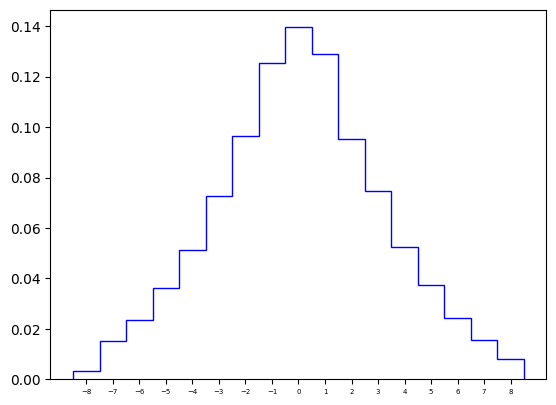

In [27]:
# Test plotting histogram for the averaged dhr in obs and ace2
plt.hist(dhr_rand/24, hr_bin_daily, color='b',histtype='step', density=True)
plt.xticks(np.arange(-8,9,1), fontsize=5)
plt.show()

# Load real statistics from ACE2 (100yr)

In [18]:
# Aggregate dhr for each basin for 100 years
i0 = 0
i1 = 0
i2 = 0
i3 = 0
i4 = 0
i5 = 0

for first_time_exe in range(1, -1, -1):

    nsub = np.size(sub_dir)
    for isub in range(0, nsub):
        
        # Load ACE2
        yrname = sub_dir[isub]
        data = np.load(file_dir_multi_yr_ace2_100yr+'TC_genesis_30SN/TCgenesis_lag_kwcrest_hr_10SN_'+yrname+'_basin.npz')
        dhr_basin0_ace2_real = data['dhr_ace2_basin0']
        dhr_basin1_ace2_real = data['dhr_ace2_basin1']
        dhr_basin2_ace2_real = data['dhr_ace2_basin2']
        dhr_basin3_ace2_real = data['dhr_ace2_basin3']
        dhr_basin4_ace2_real = data['dhr_ace2_basin4']
        dhr_basin5_ace2_real = data['dhr_ace2_basin5']

        if first_time_exe == 1:
            if isub == 0:
                size_basin_all = np.empty([nsub, nbasin])
            for ibasin in range(0, nbasin):
                tmp = globals()['dhr_basin'+str(ibasin)+'_ace2_real']
                size_basin_all[isub,ibasin] = np.size(tmp)
        else:
            if isub == 0:
                dhr_basin0_ace2_100yr_real = np.empty([ int(np.sum(size_basin_all[:,0],0)) ])
                dhr_basin1_ace2_100yr_real = np.empty([ int(np.sum(size_basin_all[:,1],0)) ])
                dhr_basin2_ace2_100yr_real = np.empty([ int(np.sum(size_basin_all[:,2],0)) ])
                dhr_basin3_ace2_100yr_real = np.empty([ int(np.sum(size_basin_all[:,3],0)) ])
                dhr_basin4_ace2_100yr_real = np.empty([ int(np.sum(size_basin_all[:,4],0)) ])
                dhr_basin5_ace2_100yr_real = np.empty([ int(np.sum(size_basin_all[:,5],0)) ])

            dhr_basin0_ace2_100yr_real[i0:i0+ int(size_basin_all[isub,0]) ] = dhr_basin0_ace2_real
            dhr_basin1_ace2_100yr_real[i1:i1+ int(size_basin_all[isub,1]) ] = dhr_basin1_ace2_real
            dhr_basin2_ace2_100yr_real[i2:i2+ int(size_basin_all[isub,2]) ] = dhr_basin2_ace2_real
            dhr_basin3_ace2_100yr_real[i3:i3+ int(size_basin_all[isub,3]) ] = dhr_basin3_ace2_real
            dhr_basin4_ace2_100yr_real[i4:i4+ int(size_basin_all[isub,4]) ] = dhr_basin4_ace2_real
            dhr_basin5_ace2_100yr_real[i5:i5+ int(size_basin_all[isub,5]) ] = dhr_basin5_ace2_real

            i0 = i0 + int( size_basin_all[isub,0] )
            i1 = i1 + int( size_basin_all[isub,1] )
            i2 = i2 + int( size_basin_all[isub,2] )
            i3 = i3 + int( size_basin_all[isub,3] )
            i4 = i4 + int( size_basin_all[isub,4] )
            i5 = i5 + int( size_basin_all[isub,5] )

# Load real statistics from obs (10 year)

In [13]:
expname_list  = list(['ace2','era5'])
iexp = 1
data = np.load(file_dir_multi_yr+'TCgenesis_lag_kwcrest_hr_10SN_'+expname_list[iexp]+'_basin.npz')
dhr_basin0_obs_real = data['dhr_basin0']
dhr_basin1_obs_real = data['dhr_basin1']
dhr_basin2_obs_real = data['dhr_basin2']
dhr_basin3_obs_real = data['dhr_basin3']
dhr_basin4_obs_real = data['dhr_basin4']
dhr_basin5_obs_real = data['dhr_basin5']

# Plot TC histogram (real statistics + hypothetical)

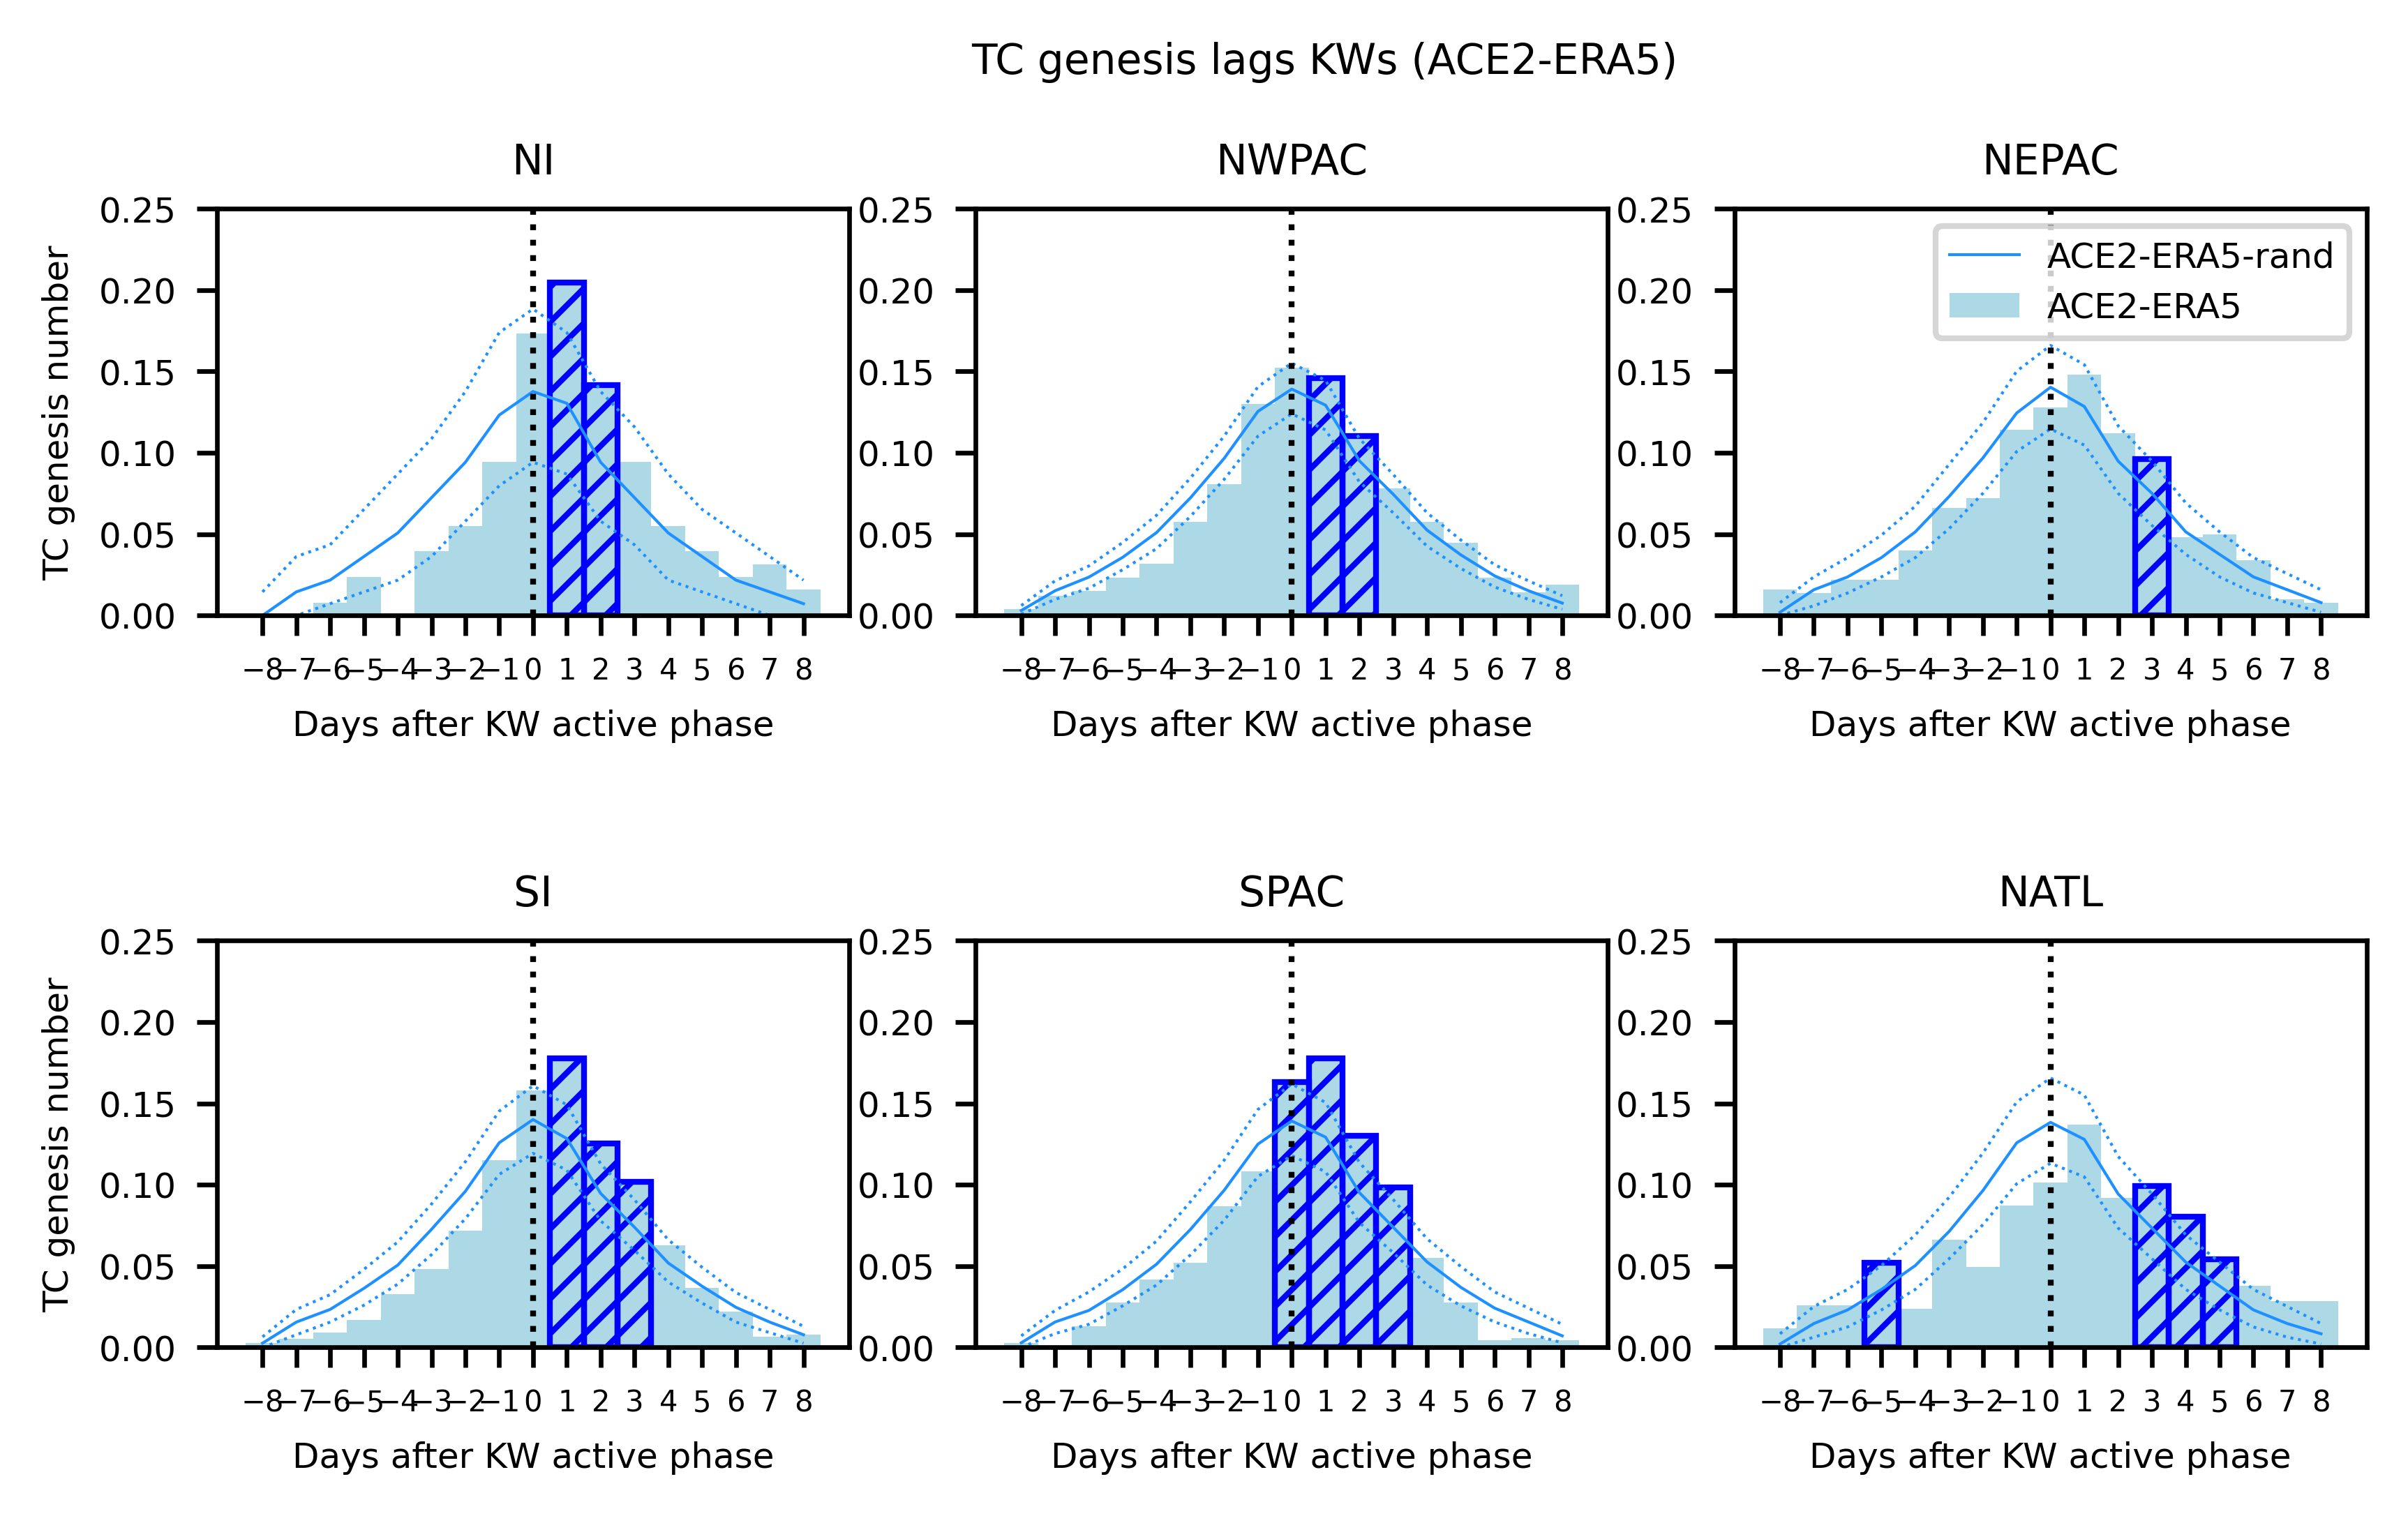

In [20]:
nbasin = 6
obs_only = 0 #0 or 1
ace2_only = 1 # 0 or 1
obs_only_list = list(['','_only_obs'])
ace2_only_list = list(['','_only_ace2'])
hr_list = list(['','_12h'])
ibasin_real = np.array([0, 1, 2, 4, 5, 3])

for bin_daily in range(1,2):
    fig_name = 'Fig.R2_KW_TCgenesis_laghr_histogram_daily_each_basin'+obs_only_list[obs_only]+ace2_only_list[ace2_only]+'_avg.png'
    fig = plt.subplots(2,3,figsize=(6.5, 4),dpi=600)
    plt.subplots_adjust(left=0.2,right=0.99,top=0.88,bottom=0.2, hspace=0.8, wspace=0.2)
    plt.rcParams.update({'font.size': 6})
    zero = np.array([0,0])
    for ibasin in range(0, nbasin):
        plt.subplot(2, 3, ibasin+1)
        '''
        dhr_tmp_ace2_rand = globals()['dhr_basin'+str(ibasin)+'_ace2_rand']
        dhr_tmp_era5_rand = globals()['dhr_basin'+str(ibasin)+'_obs_rand']
        '''
        dhr_tmp_ace2_real = globals()['dhr_basin'+str(ibasin_real[ibasin])+'_ace2_100yr_real']
        dhr_tmp_era5_real = globals()['dhr_basin'+str(ibasin_real[ibasin])+'_obs_real']
        
        dhr_tmp_ace2_rand = globals()['dhr_rand']
        dhr_tmp_era5_rand = globals()['dhr_rand']


        # Create the null hypothesis
        counts, bin_edges = np.histogram(dhr_tmp_ace2_rand/24, hr_bin_daily)
        p_ace2_rand = counts/np.nansum(counts)
        #
        counts, bin_edges = np.histogram(dhr_tmp_era5_rand/24, hr_bin_daily)
        p_obs_rand = counts/np.nansum(counts)

        bin_center = (bin_edges[1:]+bin_edges[:-1])/2
        
        # Count TC number in total
        n_ace2 = np.size(dhr_tmp_ace2_real)
        n_obs  = np.size(dhr_tmp_era5_real)

        # Find the 95th percentile for each bin (start here!!!)
        target_cdf = 0.95 #0.9 #0.95
        target_cdf2 = 0.5
        target_cdf3 = 0.05 #0.1 #0.05
        for ibin in range(0, np.size(bin_center)):
            
            if ibin == 0:
                x_95_ace2 = np.zeros(np.size(bin_center))
                x_95_obs = np.zeros(np.size(bin_center))
                x_50_ace2 = np.zeros(np.size(bin_center))
                x_50_obs = np.zeros(np.size(bin_center))
                x_5_ace2 = np.zeros(np.size(bin_center))
                x_5_obs = np.zeros(np.size(bin_center))

            x_95_ace2[ibin] = binom.ppf(target_cdf, n_ace2, p_ace2_rand[ibin])/n_ace2
            x_95_obs[ibin]  = binom.ppf(target_cdf, n_obs, p_obs_rand[ibin])/n_obs
            #
            x_50_ace2[ibin] = binom.ppf(target_cdf2, n_ace2, p_ace2_rand[ibin])/n_ace2
            x_50_obs[ibin]  = binom.ppf(target_cdf2, n_obs, p_obs_rand[ibin])/n_obs
            #
            x_5_ace2[ibin] = binom.ppf(target_cdf3, n_ace2, p_ace2_rand[ibin])/n_ace2
            x_5_obs[ibin]  = binom.ppf(target_cdf3, n_obs, p_obs_rand[ibin])/n_obs

        if bin_daily == 1:
            if obs_only == 0:
                # Compute the histogram manually
                counts, bin_edges = np.histogram(dhr_tmp_ace2_real / 24, bins=hr_bin_daily, density=True)

                # Plot the histogram using plt.bar for custom alignment
                bar_width = np.diff(bin_edges)  # Width of each bar
                plt.bar(bin_edges[:-1], counts, width=bar_width, color='lightblue', edgecolor='none', align='edge')

                # Apply hatching to specific bars
                for i in range(len(counts)):
                    if counts[i] >= x_95_ace2[i]:  # Hatch specific bars
                        if counts[i] >= 0.05 * np.sum(counts):  # At least 10%
                            plt.bar(
                                bin_edges[i],  # Left edge of the bar
                                counts[i],  # Height of the bar
                                width=bar_width[i],  # Width of the bar
                                color='none',  # Transparent face
                                edgecolor='b',  # Hatch color
                                hatch='////',  # Hatch pattern
                                align='edge',
                            )
                plt.plot(bin_center, x_50_ace2, color='dodgerblue', linewidth=0.5, linestyle='solid')
                if ibasin == 2:
                    plt.legend(['ACE2-ERA5-rand','ACE2-ERA5'])
                plt.plot(bin_center, x_95_ace2, color='dodgerblue', linewidth=0.5, linestyle=':')#, marker='.', markersize=2)
                plt.plot(bin_center, x_5_ace2, color='dodgerblue', linewidth=0.5, linestyle=':')
            if ace2_only == 0:
                #plt.hist(dhr_tmp_era5_rand/24, hr_bin_daily, color='grey', density=True, label=':',histtype='step')
                plt.hist(dhr_tmp_era5_real/24, hr_bin_daily, density=True, color='k',label=':',histtype='step') 
                plt.plot(bin_center, x_95_obs, color='grey', linewidth=0.5, linestyle=':')#, marker='.', markersize=2)
            plt.xlabel('Days after KW active phase')
            plt.xticks(np.arange(-8,9,1), fontsize=5)
            #plt.xticks(np.arange(-5,6,1), fontsize=5.5)
            plt.plot(zero, [0,1], color='k',linestyle=':', linewidth=1)
            plt.ylim([0, 0.25])
        
        if ibasin == 0 or ibasin == 3:
            plt.ylabel('TC genesis number')
        plt.title(basin_list[ibasin_real[ibasin]])
    plt.suptitle('                                            TC genesis lags KWs (ACE2-ERA5)')
    plt.savefig(fig_dir+fig_name,format='png', dpi=600)
    plt.show()
    plt.close()

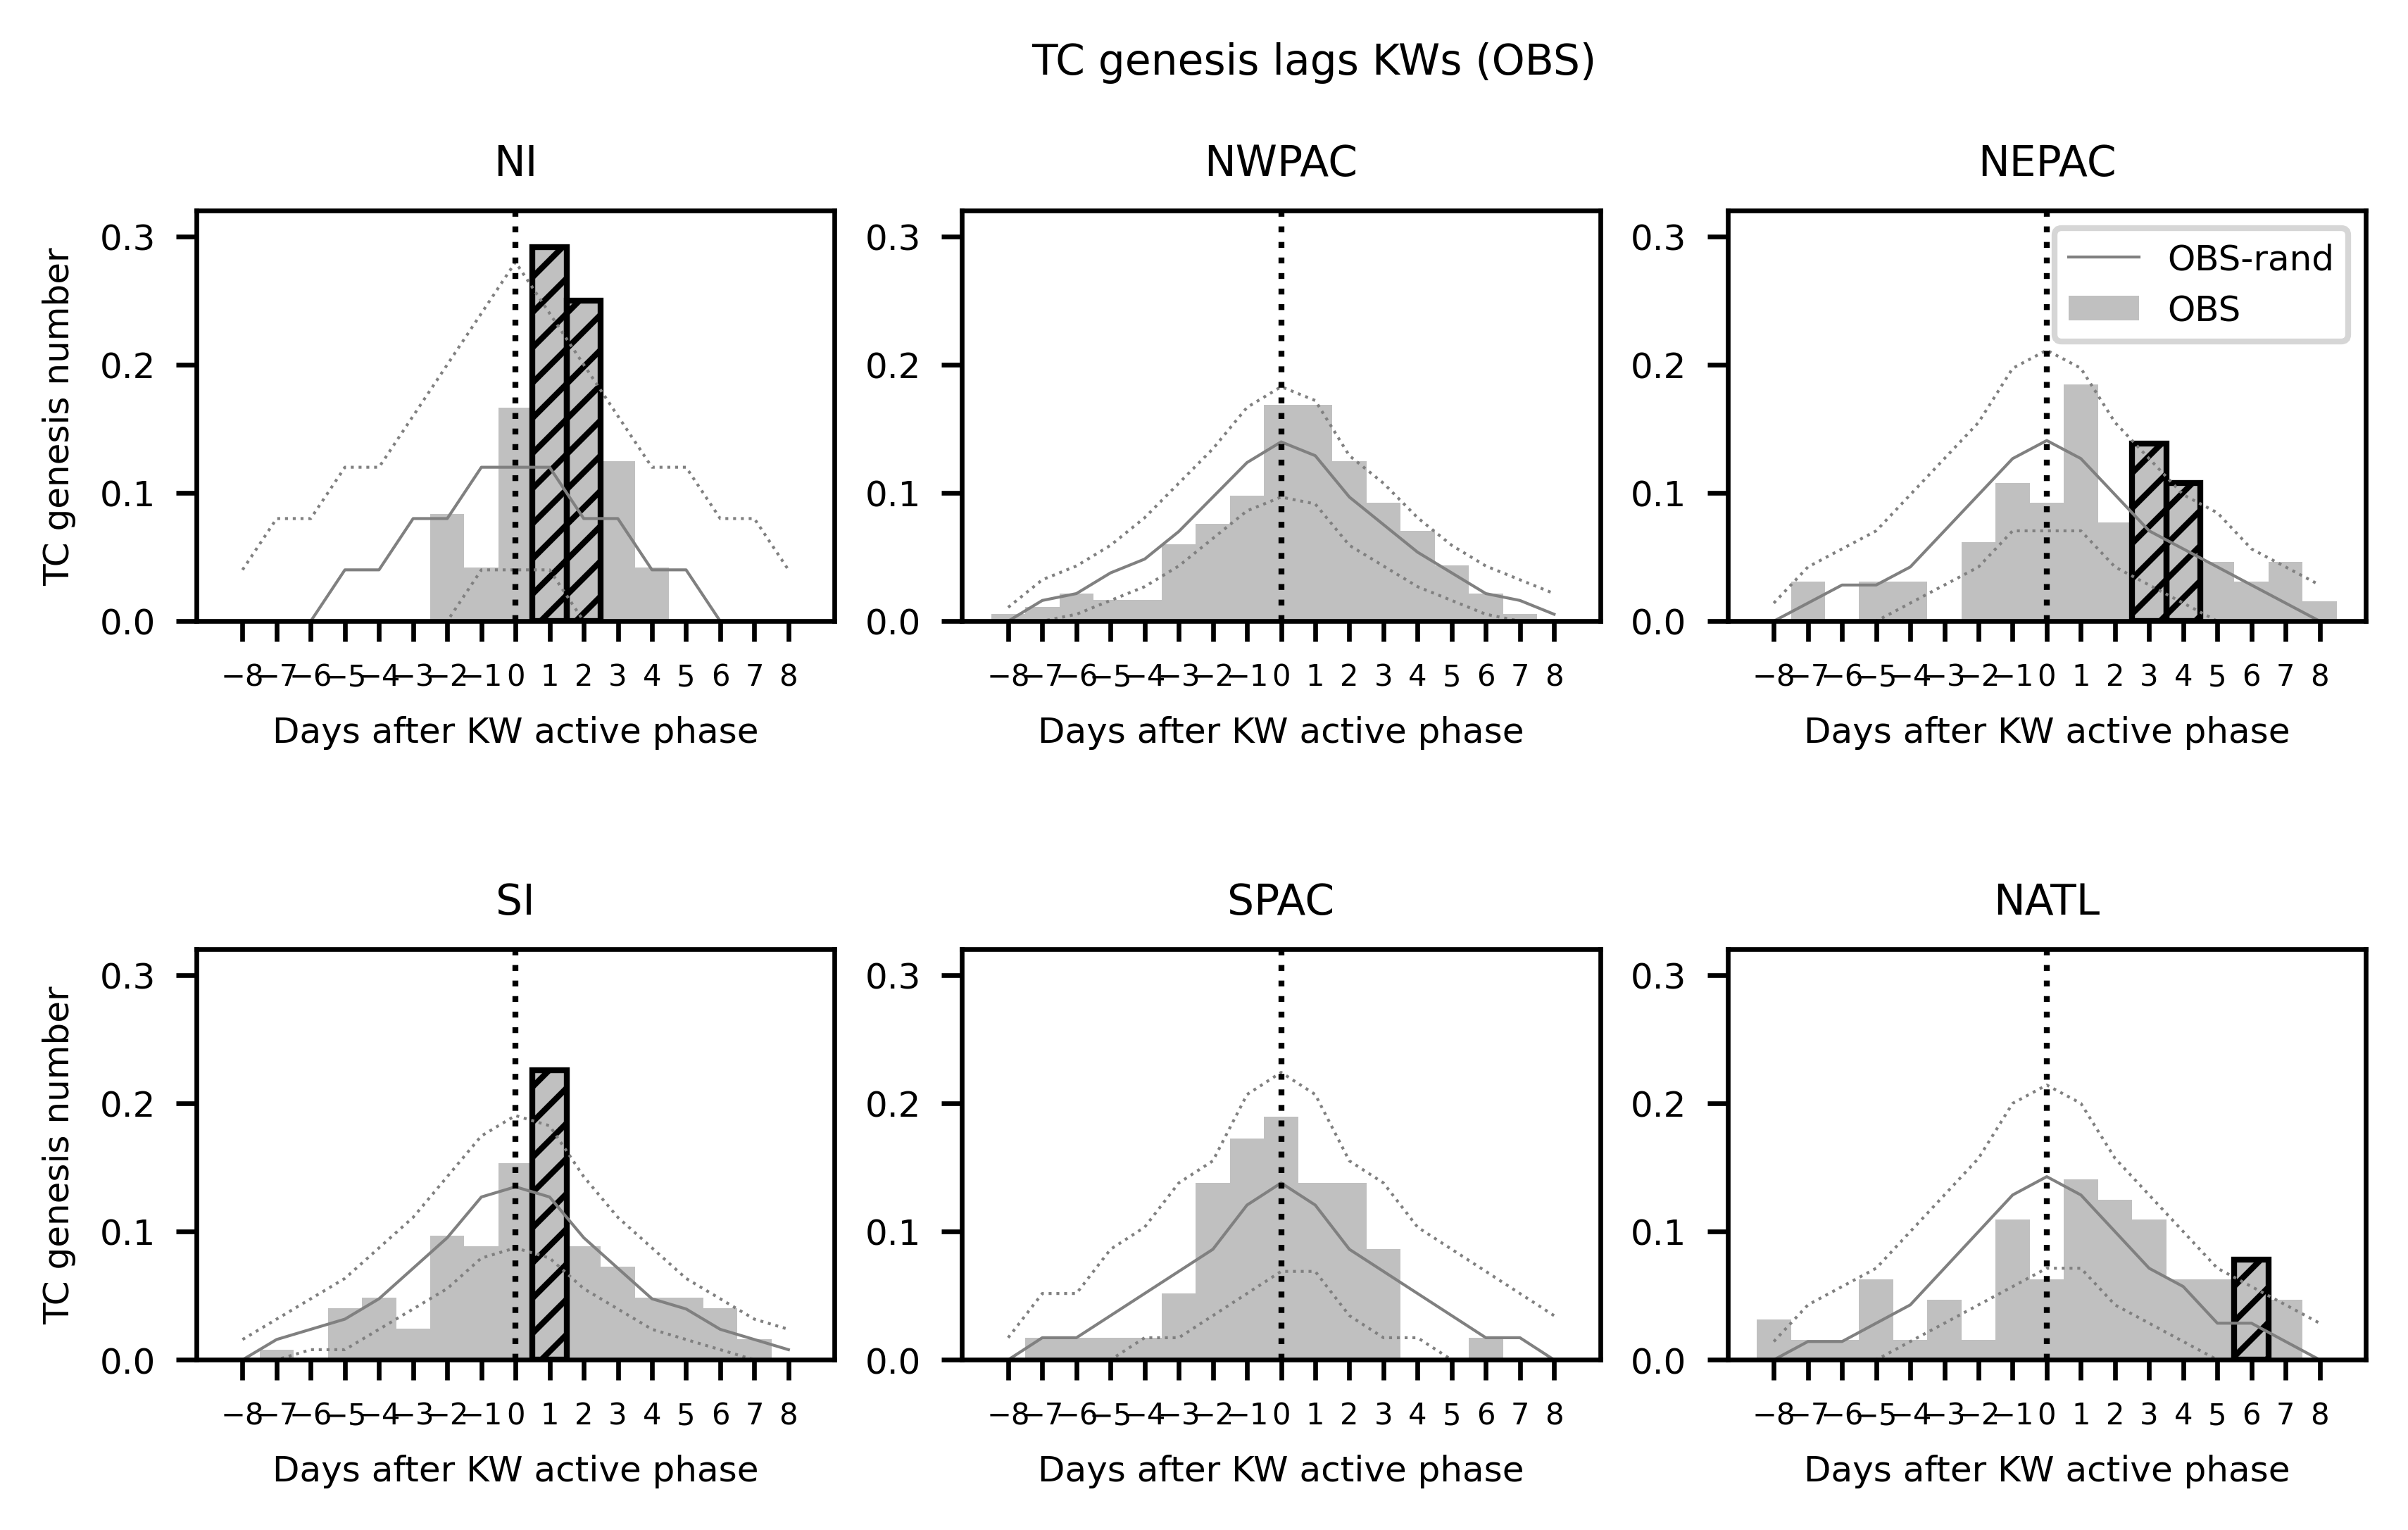

In [29]:
nbasin = 6
obs_only = 1 #0 or 1
ace2_only = 0 # 0 or 1
obs_only_list = list(['','_only_obs'])
ace2_only_list = list(['','_only_ace2'])
hr_list = list(['','_12h'])
for bin_daily in range(1,2):
    fig_name = 'Fig.R2_KW_TCgenesis_laghr_histogram_daily_each_basin'+obs_only_list[obs_only]+ace2_only_list[ace2_only]+'_avg.png'
    fig = plt.subplots(2,3,figsize=(6.5, 4),dpi=600)
    plt.subplots_adjust(left=0.2,right=0.99,top=0.88,bottom=0.2, hspace=0.8, wspace=0.2)
    plt.rcParams.update({'font.size': 6})
    zero = np.array([0,0])
    for ibasin in range(0, nbasin):
        plt.subplot(2, 3, ibasin+1)
        #dhr_tmp_ace2_rand = globals()['dhr_basin'+str(ibasin)+'_ace2_rand']
        #dhr_tmp_era5_rand = globals()['dhr_basin'+str(ibasin)+'_obs_rand']
        dhr_tmp_ace2_real = globals()['dhr_basin'+str(ibasin_real[ibasin])+'_ace2_100yr_real']
        dhr_tmp_era5_real = globals()['dhr_basin'+str(ibasin_real[ibasin])+'_obs_real']

        dhr_tmp_ace2_rand = globals()['dhr_rand']
        dhr_tmp_era5_rand = globals()['dhr_rand']

        # Create the null hypothesis
        counts, bin_edges = np.histogram(dhr_tmp_ace2_rand/24, hr_bin_daily)
        p_ace2_rand = counts/np.nansum(counts)
        #
        counts, bin_edges = np.histogram(dhr_tmp_era5_rand/24, hr_bin_daily)
        p_obs_rand = counts/np.nansum(counts)

        bin_center = (bin_edges[1:]+bin_edges[:-1])/2
        
        # Count TC number in total
        n_ace2 = np.size(dhr_tmp_ace2_real)
        n_obs  = np.size(dhr_tmp_era5_real)

        # Find the 95th percentile for each bin (start here!!!)
        target_cdf = 0.95 #0.9 #0.95
        target_cdf2 = 0.5
        target_cdf3 = 0.05 #0.1 #0.05
        for ibin in range(0, np.size(bin_center)):
            
            if ibin == 0:
                x_95_ace2 = np.zeros(np.size(bin_center))
                x_95_obs = np.zeros(np.size(bin_center))
                x_50_ace2 = np.zeros(np.size(bin_center))
                x_50_obs = np.zeros(np.size(bin_center))
                x_5_ace2 = np.zeros(np.size(bin_center))
                x_5_obs = np.zeros(np.size(bin_center))

            x_95_ace2[ibin] = binom.ppf(target_cdf, n_ace2, p_ace2_rand[ibin])/n_ace2
            x_95_obs[ibin]  = binom.ppf(target_cdf, n_obs, p_obs_rand[ibin])/n_obs
            #
            x_50_ace2[ibin] = binom.ppf(target_cdf2, n_ace2, p_ace2_rand[ibin])/n_ace2
            x_50_obs[ibin]  = binom.ppf(target_cdf2, n_obs, p_obs_rand[ibin])/n_obs
            #
            x_5_ace2[ibin] = binom.ppf(target_cdf3, n_ace2, p_ace2_rand[ibin])/n_ace2
            x_5_obs[ibin]  = binom.ppf(target_cdf3, n_obs, p_obs_rand[ibin])/n_obs

        if bin_daily == 1:
            if obs_only == 0:
                #plt.hist(dhr_tmp_ace2_rand/24, hr_bin_daily , color='c', density=True, label=':',histtype='step')
                counts, bins, patches = plt.hist(dhr_tmp_ace2_real/24, hr_bin_daily, density=True, color='b')#,histtype='step')
                # Apply hatching to specific bars
                for i, patch in enumerate(patches):
                    if counts[i]>=x_95_obs[i]:  # Hatch specific bars (e.g., 3rd, 6th, and 8th bars)
                        if counts[i]>=0.05*np.sum(counts): # At least 10%
                            patch.set_hatch('////')  # Hatch pattern (e.g., '//') 
                        
                
                plt.plot(bin_center, x_50_ace2, color='dodgerblue', linewidth=0.5, linestyle='solid')
                if ibasin == 2:
                    plt.legend(['OBS-rand','OBS'])
                plt.plot(bin_center, x_95_ace2, color='dodgerblue', linewidth=0.5, linestyle=':')#, marker='.', markersize=2)
                plt.plot(bin_center, x_5_ace2, color='dodgerblue', linewidth=0.5, linestyle=':')
            if ace2_only == 0:
                # Compute the histogram manually
                counts, bin_edges = np.histogram(dhr_tmp_era5_real / 24, bins=hr_bin_daily, density=True)

                # Plot the histogram using plt.bar for custom alignment
                bar_width = np.diff(bin_edges)  # Width of each bar
                plt.bar(bin_edges[:-1], counts, width=bar_width, color='silver', edgecolor='none', align='edge')

                # Apply hatching to specific bars
                for i in range(len(counts)):
                    if counts[i] >= x_95_obs[i]:  # Hatch specific bars
                        if counts[i] >= 0.05 * np.sum(counts):  # At least 10%
                            plt.bar(
                                bin_edges[i],  # Left edge of the bar
                                counts[i],  # Height of the bar
                                width=bar_width[i],  # Width of the bar
                                color='none',  # Transparent face
                                edgecolor='k',  # Hatch color
                                hatch='////',  # Hatch pattern
                                align='edge',
                            )
                plt.plot(bin_center, x_50_obs, color='grey', linewidth=0.5, linestyle='solid')
                if ibasin == 2:
                    plt.legend(['OBS-rand','OBS'])
                plt.plot(bin_center, x_95_obs, color='grey', linewidth=0.5, linestyle=':')#, marker='.', markersize=2)
                plt.plot(bin_center, x_5_obs, color='grey', linewidth=0.5, linestyle=':')
            plt.xlabel('Days after KW active phase')
            plt.xticks(np.arange(-8,9,1), fontsize=5)
            #plt.xticks(np.arange(-5,6,1), fontsize=5.5)
            plt.plot(zero, [0,1], color='k',linestyle=':', linewidth=1)
            plt.ylim([0, 0.32])
    
        if ibasin == 0 or ibasin == 3:
            plt.ylabel('TC genesis number')
        plt.title(basin_list[ibasin_real[ibasin]])
    plt.suptitle('                                            TC genesis lags KWs (OBS)')
    plt.savefig(fig_dir+fig_name,format='png', dpi=600)
    plt.show()
    plt.close()

# Test: plot anomalies of TC genesis compared to normal distribution in terms of lag days from KWs 

In [15]:
ibasin_goal = np.array([0, 1, 4, 5, 2, 3])

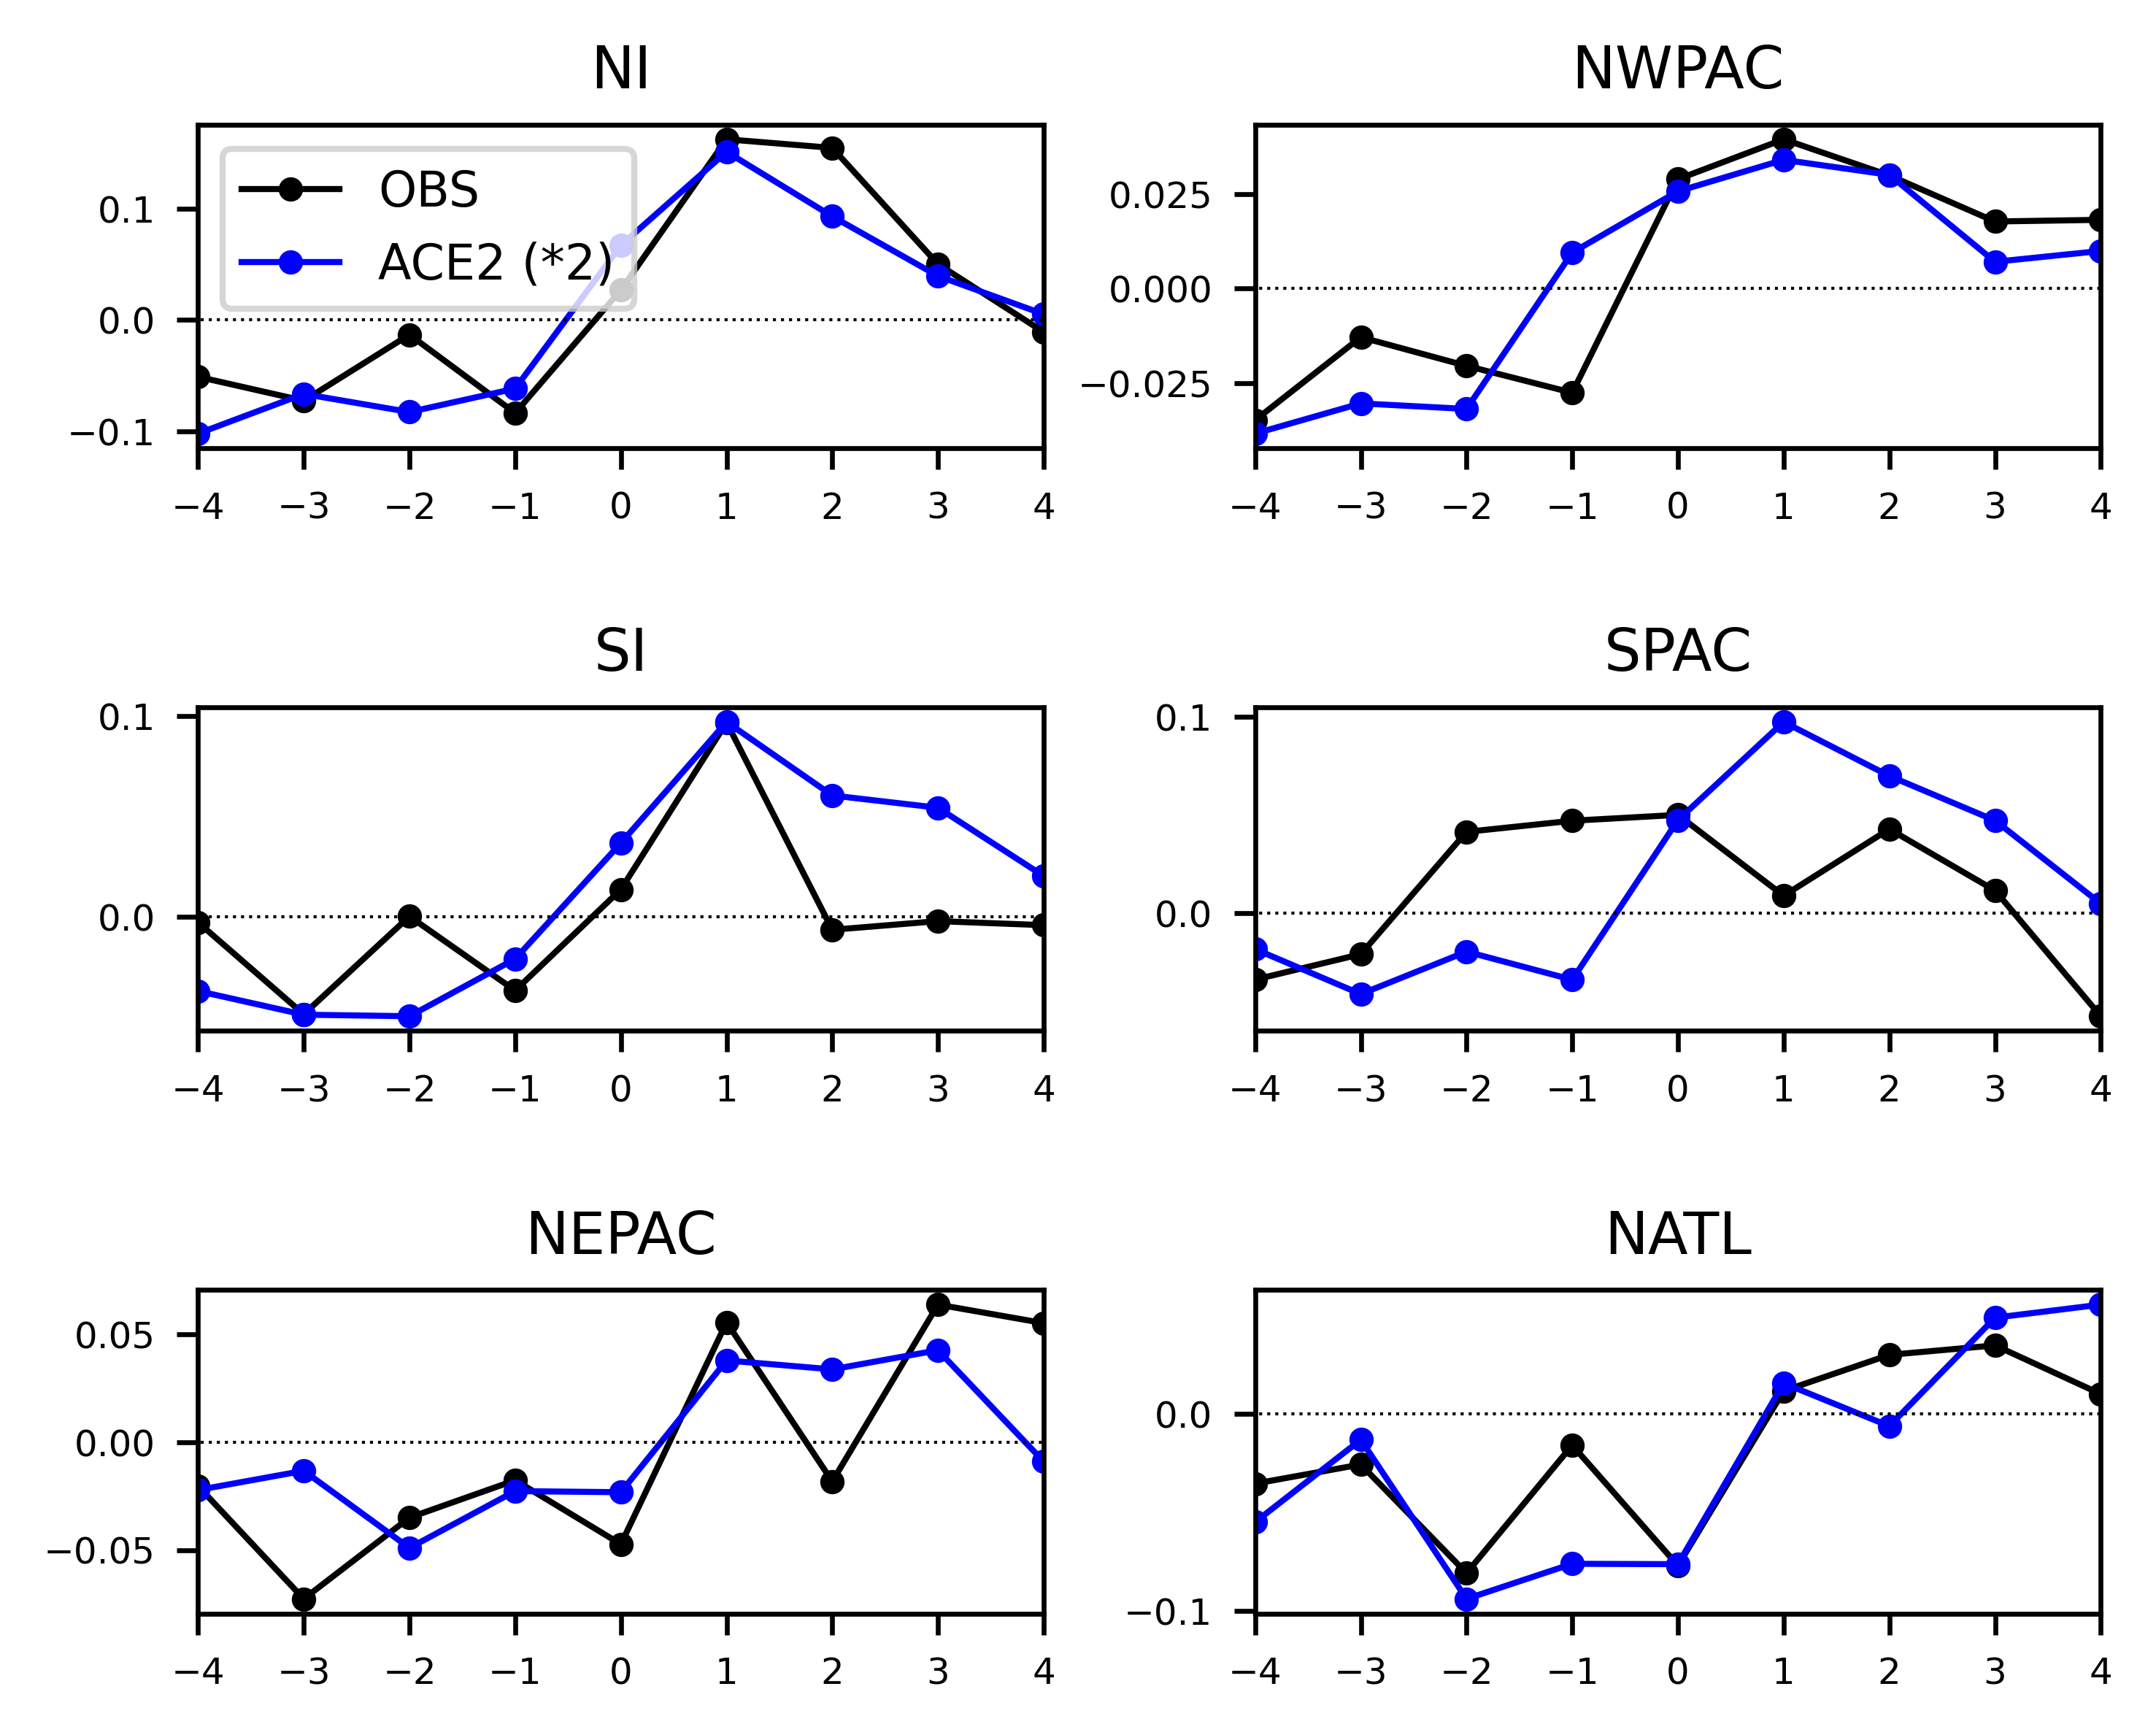

In [21]:
# Plot TC anomaly (only up to +-4 days)
fig_name = 'Fig.R4_KWcomposite_TCano.png'
fig = plt.subplots(3,2,figsize=(5.5, 5),dpi=600)
plt.subplots_adjust(left=0.2,right=0.99,top=0.88,bottom=0.2, hspace=0.8, wspace=0.25)
plt.rcParams.update({'font.size': 8})
for ibasin in range(0, nbasin):
    plt.subplot(3, 2, ibasin+1)
    dhr_tmp_ace2_real = globals()['dhr_basin'+str(ibasin_goal[ibasin])+'_ace2_100yr_real']
    dhr_tmp_era5_real = globals()['dhr_basin'+str(ibasin_goal[ibasin])+'_obs_real']

    TC_obs, bin_edges = np.histogram(dhr_tmp_era5_real / 24, bins=hr_bin_daily, density=True)
    TC_rand_obs = np.sum(TC_obs) * p_obs_rand
    TC_obs_ano = TC_obs - TC_rand_obs
    
    TC_ace2, bin_edges = np.histogram(dhr_tmp_ace2_real / 24, bins=hr_bin_daily, density=True)
    TC_rand_ace2 = np.sum(TC_ace2) * p_ace2_rand
    TC_ace2_ano = TC_ace2 - TC_rand_ace2

    plt.plot(bin_center, TC_obs_ano, color='k', linewidth=1, linestyle='solid', marker='o', markersize=3)
    plt.plot(bin_center, TC_ace2_ano*2, color='b', linewidth=1, linestyle='solid', marker='o', markersize=3)
    if ibasin == 0:
        plt.legend(['OBS','ACE2 (*2)'])
    plt.title(basin_list[ibasin_goal[ibasin]])
    plt.xlim([-4, 4])
    plt.xticks(np.arange(-4,5,1))
    plt.plot(bin_center, np.zeros([np.size(bin_center)]), color='k', linestyle=':', linewidth=0.5)
plt.show()

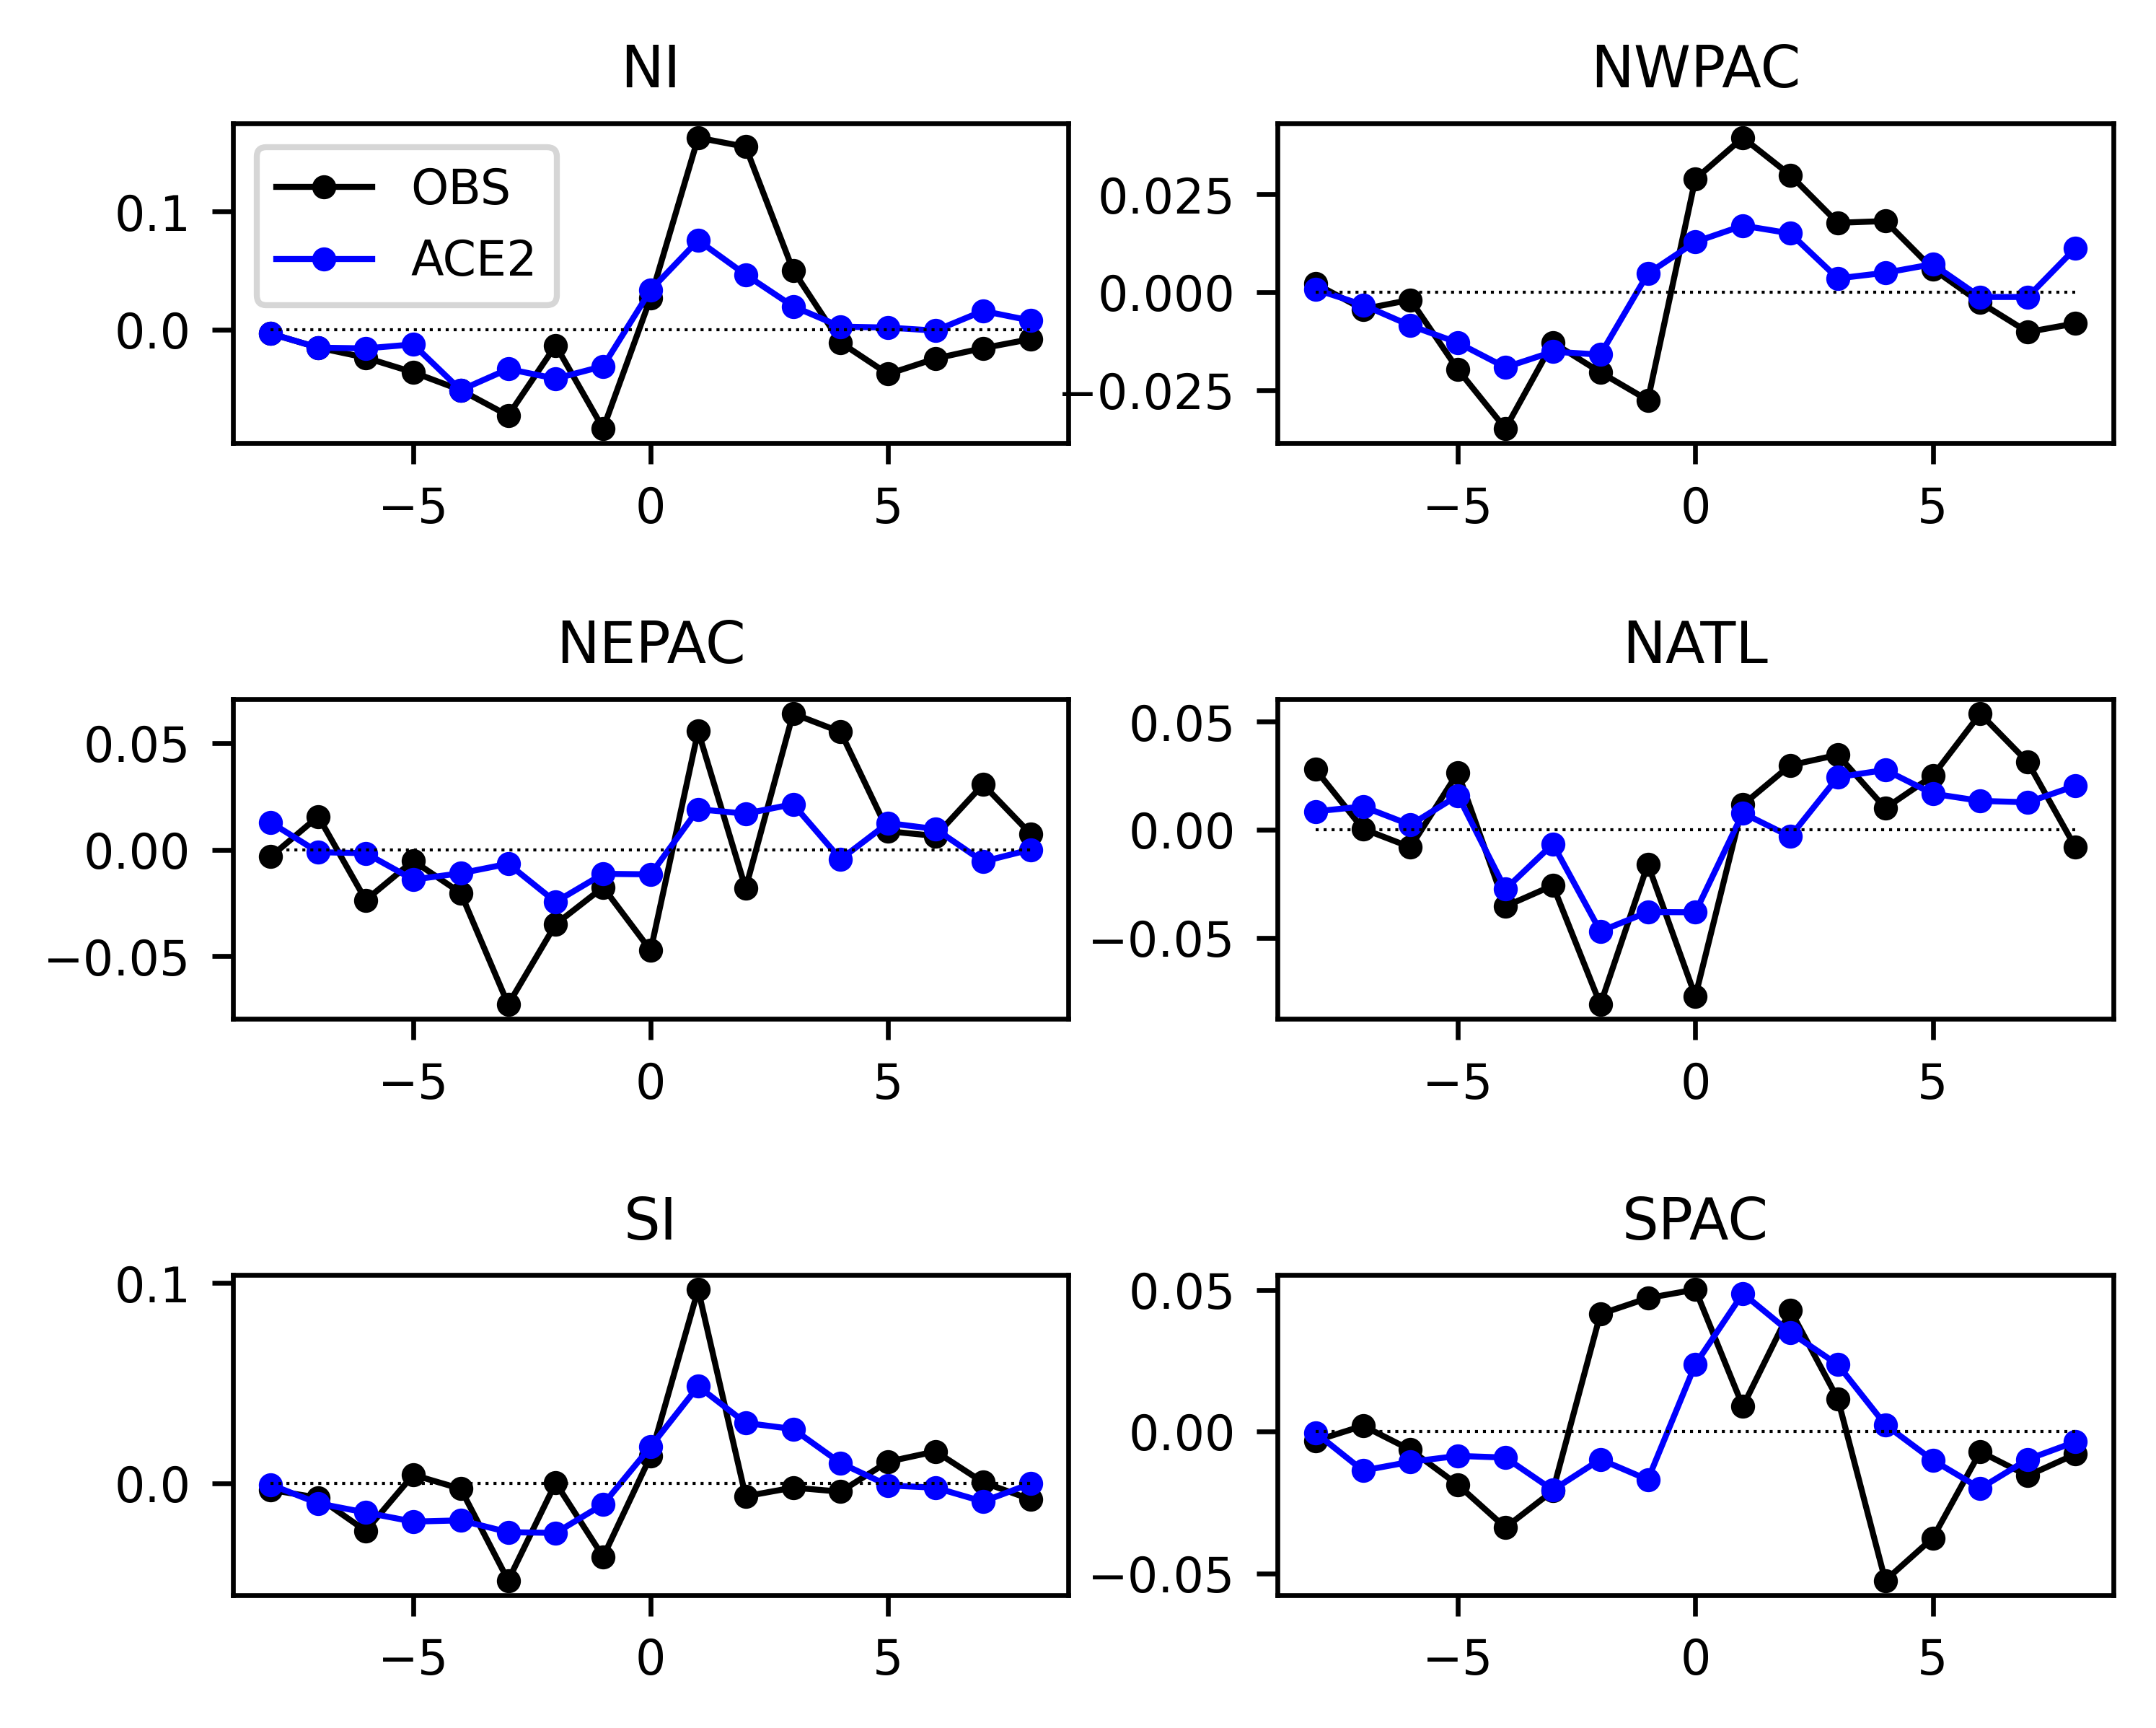

In [23]:
# Plot TC anomaly (only up to +-8 days)
fig_name = 'Fig.R4_KWcomposite_TCano.png'
fig = plt.subplots(3,2,figsize=(5.5, 5),dpi=600)
plt.subplots_adjust(left=0.2,right=0.99,top=0.88,bottom=0.2, hspace=0.8, wspace=0.25)
plt.rcParams.update({'font.size': 8})
for ibasin in range(0, nbasin):
    plt.subplot(3, 2, ibasin+1)
    dhr_tmp_ace2_real = globals()['dhr_basin'+str(ibasin)+'_ace2_100yr_real']
    dhr_tmp_era5_real = globals()['dhr_basin'+str(ibasin)+'_obs_real']

    TC_obs, bin_edges = np.histogram(dhr_tmp_era5_real / 24, bins=hr_bin_daily, density=True)
    TC_rand_obs = np.sum(TC_obs) * p_obs_rand

    if ibasin == 0:
        TC_obs_ano = np.empty([np.size(bin_center),nbasin])
        TC_ace2_ano = np.empty([np.size(bin_center),nbasin])

    TC_obs_ano[:, ibasin] = TC_obs - TC_rand_obs
    
    TC_ace2, bin_edges = np.histogram(dhr_tmp_ace2_real / 24, bins=hr_bin_daily, density=True)
    TC_rand_ace2 = np.sum(TC_ace2) * p_ace2_rand
    TC_ace2_ano[:, ibasin] = TC_ace2 - TC_rand_ace2

    plt.plot(bin_center, TC_obs_ano[:, ibasin], color='k', linewidth=1, linestyle='solid', marker='o', markersize=3)
    plt.plot(bin_center, TC_ace2_ano[:, ibasin], color='b', linewidth=1, linestyle='solid', marker='o', markersize=3)
    if ibasin == 0:
        plt.legend(['OBS','ACE2'])
    plt.title(basin_list[ibasin])
    #plt.xlim([-4, 4])
    #plt.xticks(np.arange(-4,5,1))
    plt.plot(bin_center, np.zeros([np.size(bin_center)]), color='k', linestyle=':', linewidth=0.5)
plt.show()

In [24]:
# Save TC anomaly
np.savez(file_dir_multi_yr_ace2_100yr + 'TCgenesis_lag_kwcrest_TCano_daily.npz', bin_center=bin_center, TC_obs_ano=TC_obs_ano, TC_ace2_ano=TC_ace2_ano)

# Check correlation between TC genesis and env factor

In [76]:
# Load TCGI lag regression from ACE2 (100yr)
data = np.load(file_dir_multi_yr_ace2_100yr+'TCGI_KW_lag_regression_basin_ace2_100yr.npz')
TCGI_lag_kw_basin_ace2         = data['TCGI_lag_kw_basin_ace2']
shear_lag_kw_basin_ace2        = data['shear_lag_kw_basin_ace2']
col_rh_lag_kw_basin_ace2       = data['col_rh_lag_kw_basin_ace2']
abs_vor_clip_lag_kw_basin_ace2 = data['abs_vor_clip_lag_kw_basin_ace2']
#abs_vor_lag_kw_basin_ace2=abs_vor_lag_kw_basin_ace2,\
relsst_lag_kw_basin_ace2 = data['relsst_lag_kw_basin_ace2']
lags                     = data['lags']
basin_list               = data['basin_list']

# Load TCGI lag regression from OBS (10yr)
data = np.load(file_dir_multi_yr+'TCGI_KW_lag_regression_basin_era5.npz')
TCGI_lag_kw_basin_era5         = data['TCGI_lag_kw_basin_era5']
shear_lag_kw_basin_era5        = data['shear_lag_kw_basin_era5']
col_rh_lag_kw_basin_era5       = data['col_rh_lag_kw_basin_era5']
abs_vor_clip_lag_kw_basin_era5 = data['abs_vor_clip_lag_kw_basin_era5']
#abs_vor_lag_kw_basin_era5=abs_vor_lag_kw_basin_era5,\
relsst_lag_kw_basin_era5 = data['relsst_lag_kw_basin_era5']

In [93]:
# only use daily data for KW composite so that it matches the TC data
lags_daily = np.arange(-8, 9, 1) 
for i in range(0, np.size(lags_daily)):
    if i == 0:
        ilag = np.empty([np.size(lags_daily)], dtype=int)
    ilag[i] = np.argwhere(lags==lags_daily[i]).squeeze()


In [94]:
print(ilag)

[ 0  4  8 12 16 20 24 28 32 36 40 44 48 52 56 60 64]


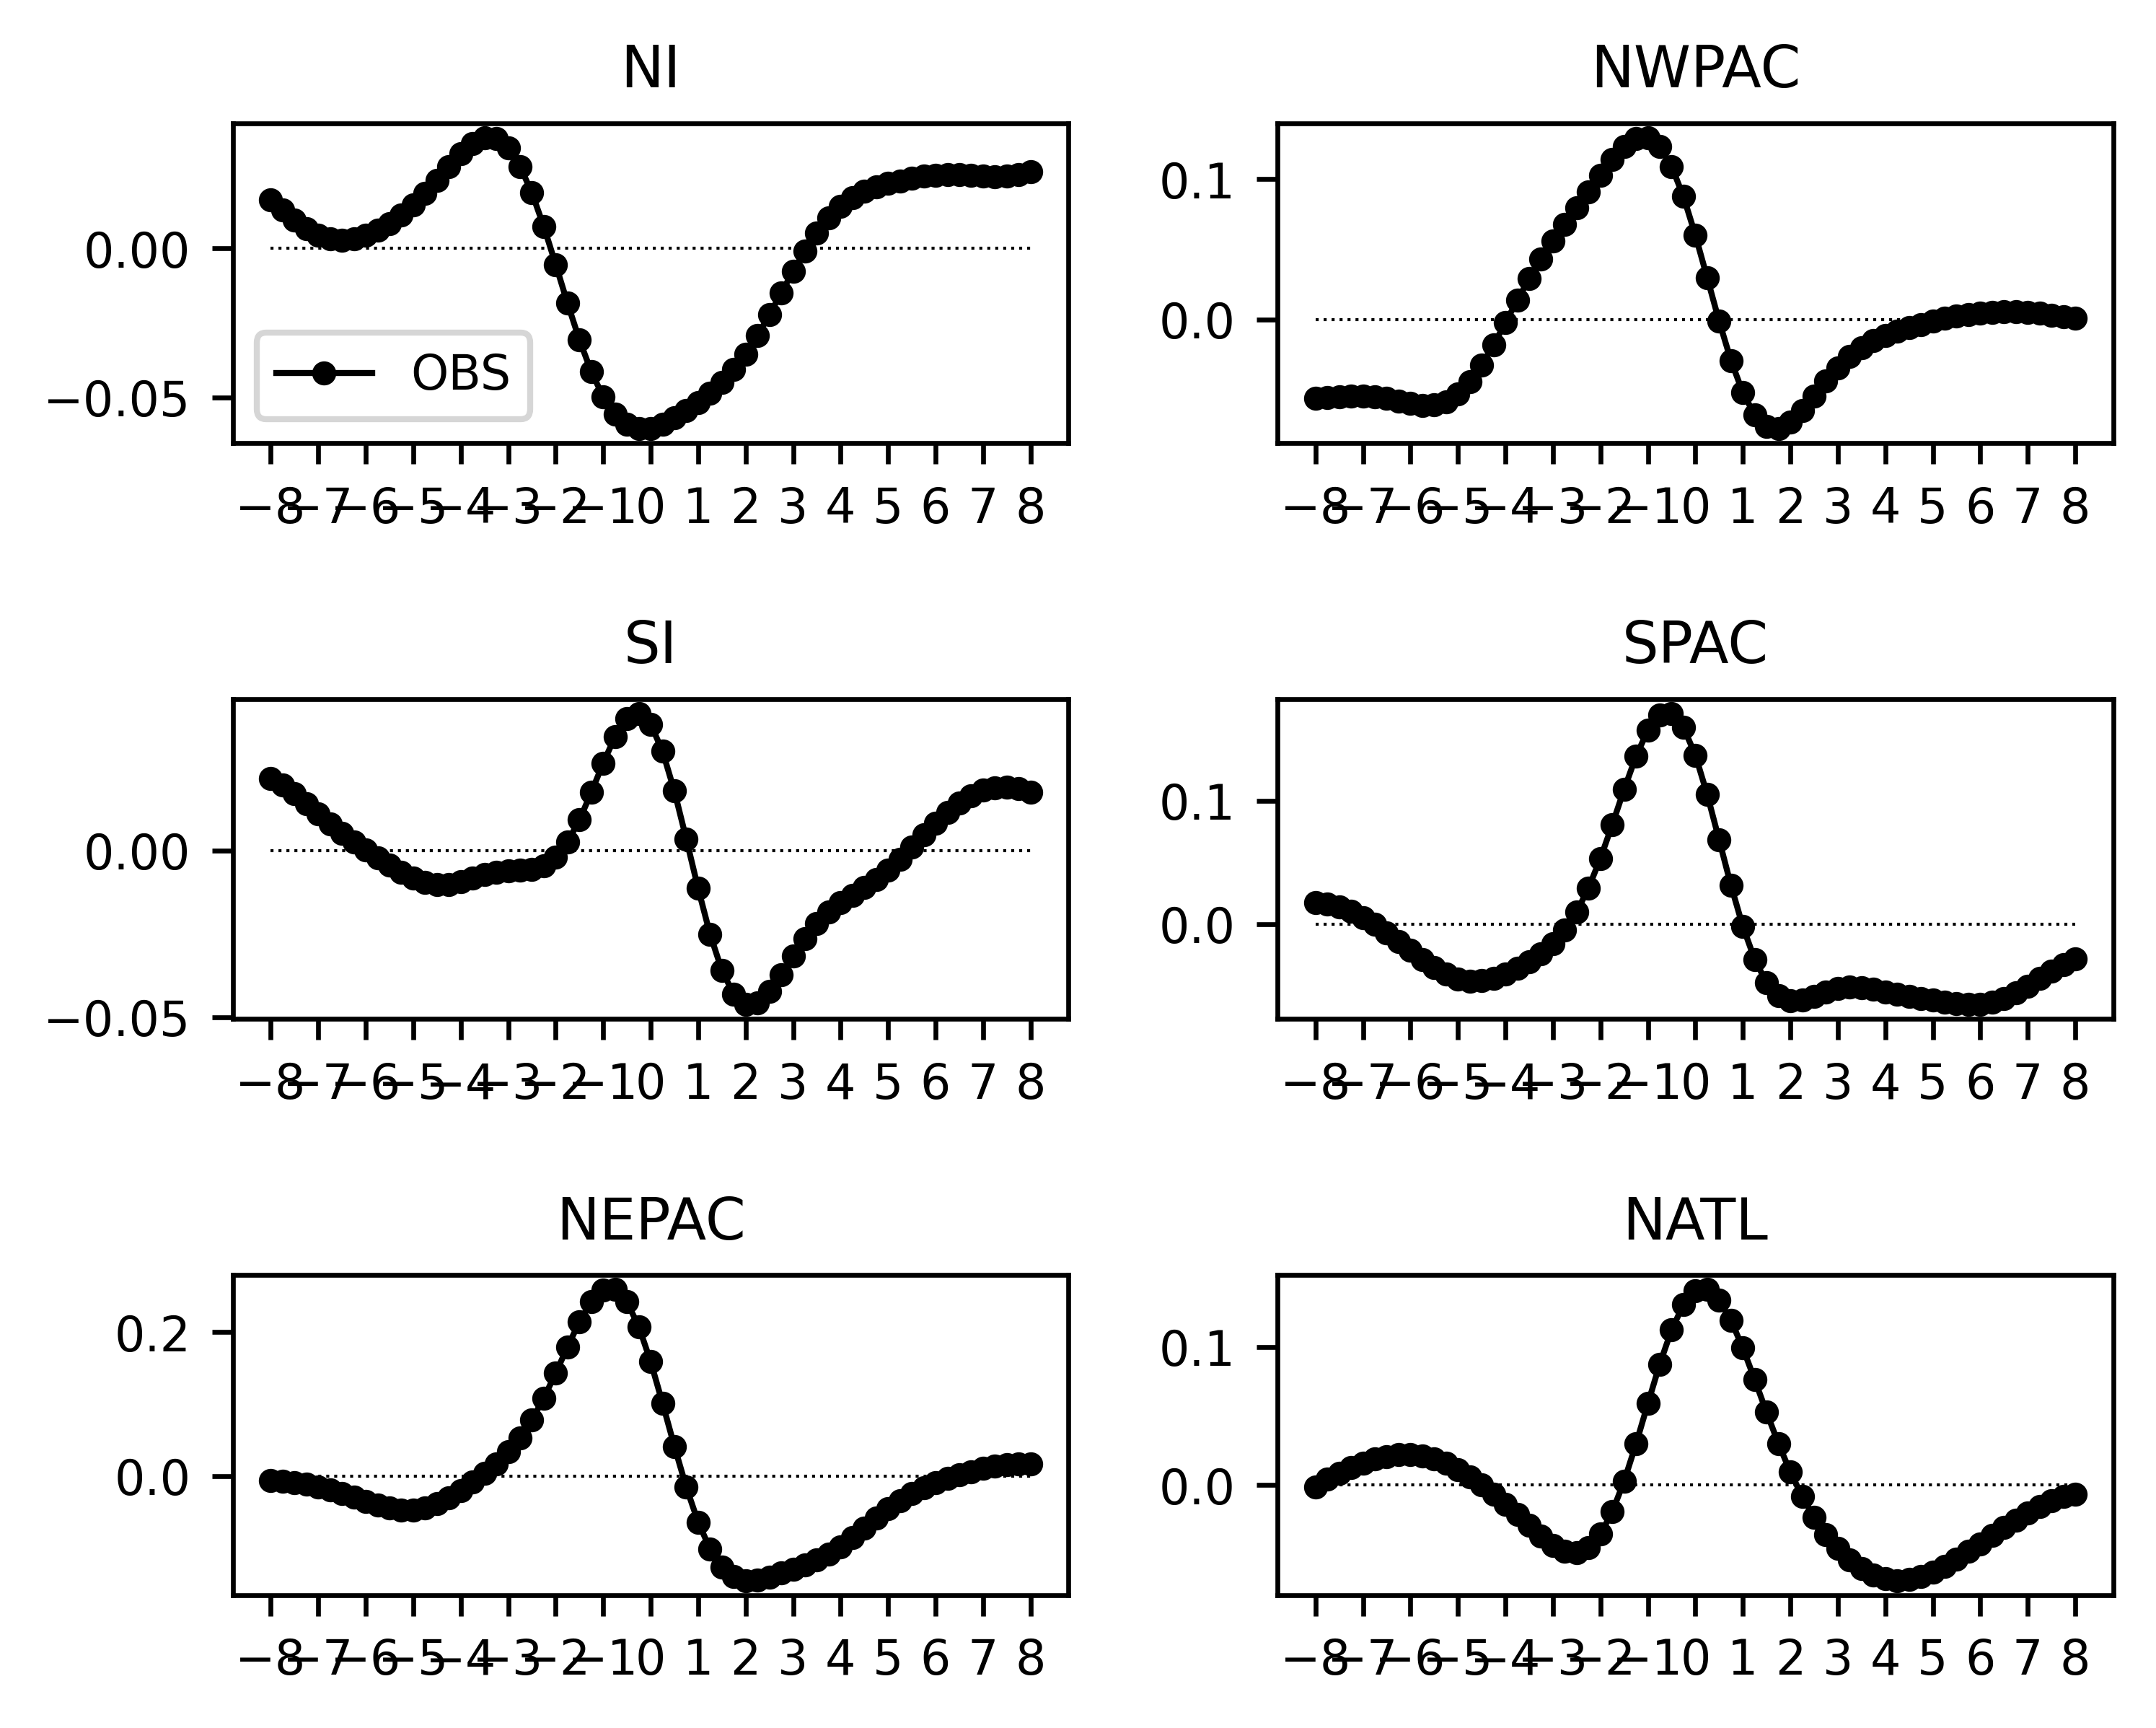

In [81]:
fig_name = 'Fig.R4_KWcomposite_envfactor.png'
fig = plt.subplots(3,2,figsize=(5.5, 5),dpi=600)
plt.subplots_adjust(left=0.2,right=0.99,top=0.88,bottom=0.2, hspace=0.8, wspace=0.25)
plt.rcParams.update({'font.size': 8})
for ibasin in range(0, nbasin):
    plt.subplot(3, 2, ibasin+1)
    plt.plot(lags, shear_lag_kw_basin_ace2[:,ibasin_goal[ibasin]], color='k', linewidth=1, linestyle='solid', marker='o', markersize=3)
    #plt.plot(bin_center, TC_ace2_ano, color='b', linewidth=1, linestyle='solid', marker='o', markersize=3)
    if ibasin == 0:
        plt.legend(['OBS','ACE2'])
    plt.title(basin_list[ibasin_goal[ibasin]])
    #plt.xlim([-4, 4])
    plt.xticks(np.arange(-8,9,1))
    plt.plot(bin_center, np.zeros([np.size(bin_center)]), color='k', linestyle=':', linewidth=0.5)
plt.show()

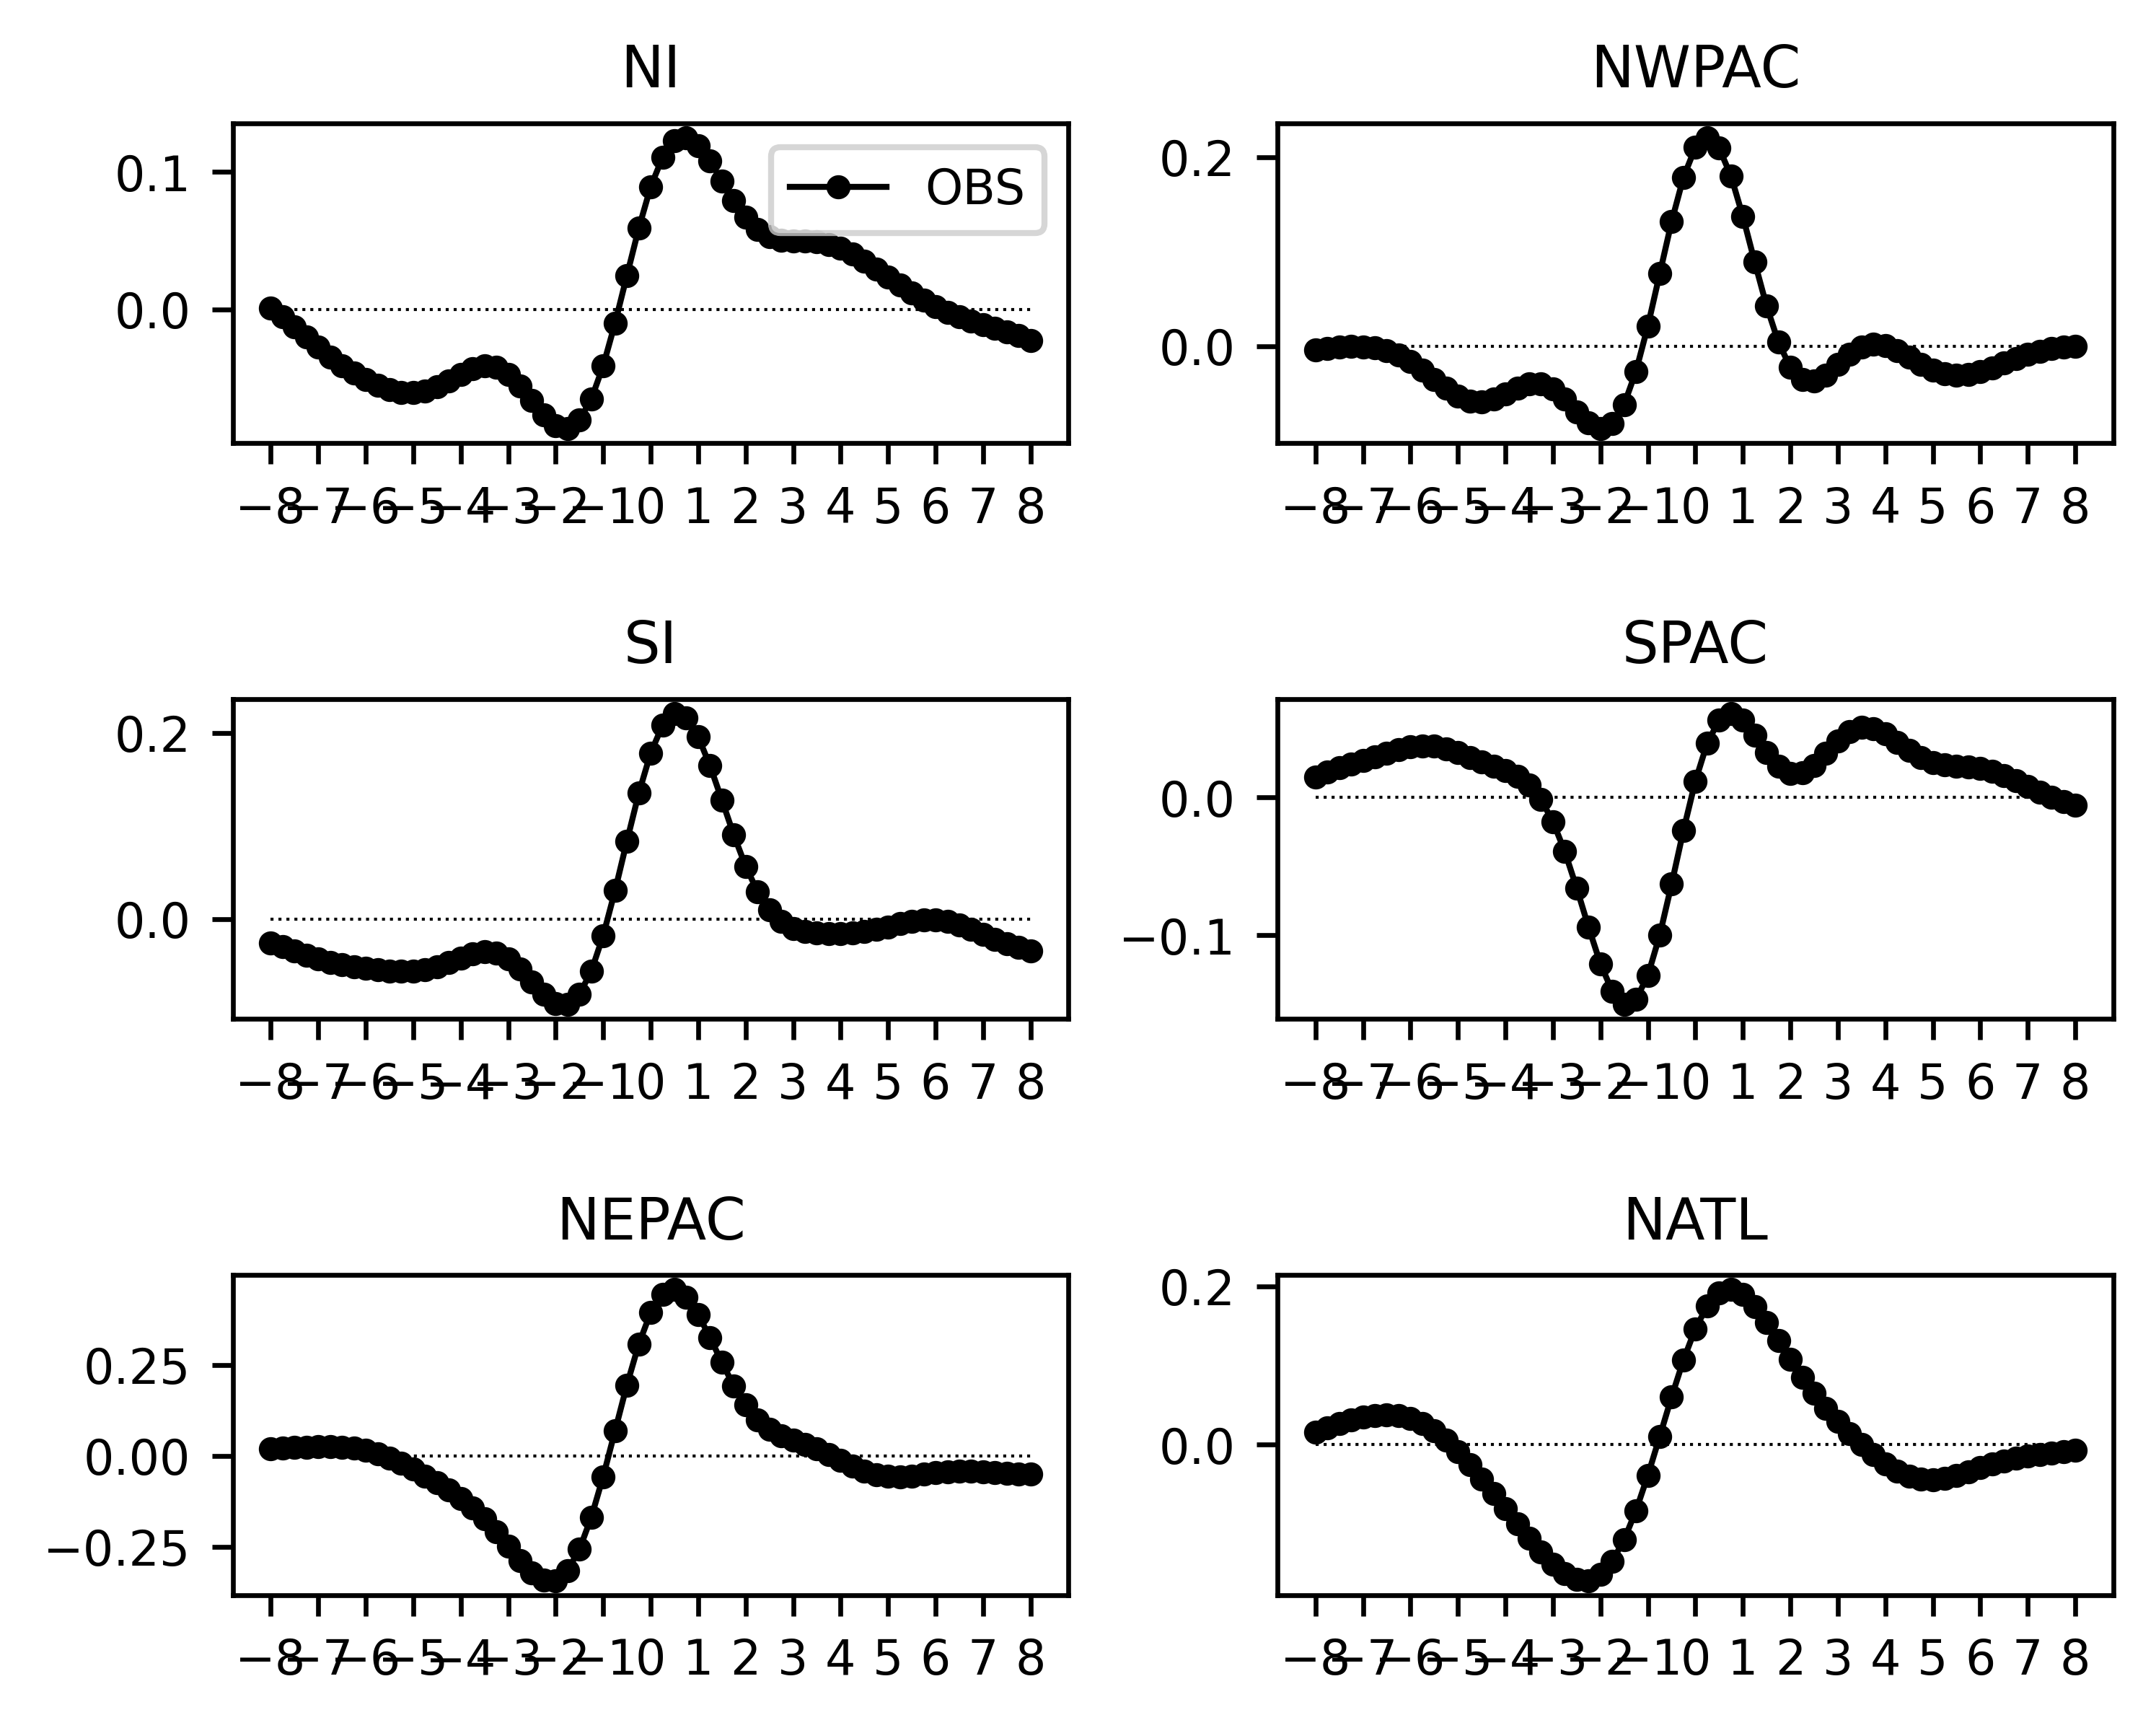

In [83]:
fig_name = 'Fig.R4_KWcomposite_envfactor.png'
fig = plt.subplots(3,2,figsize=(5.5, 5),dpi=600)
plt.subplots_adjust(left=0.2,right=0.99,top=0.88,bottom=0.2, hspace=0.8, wspace=0.25)
plt.rcParams.update({'font.size': 8})
for ibasin in range(0, nbasin):
    plt.subplot(3, 2, ibasin+1)
    plt.plot(lags, col_rh_lag_kw_basin_ace2[:,ibasin_goal[ibasin]], color='k', linewidth=1, linestyle='solid', marker='o', markersize=3)
    #plt.plot(bin_center, TC_ace2_ano, color='b', linewidth=1, linestyle='solid', marker='o', markersize=3)
    if ibasin == 0:
        plt.legend(['OBS','ACE2'])
    plt.title(basin_list[ibasin_goal[ibasin]])
    #plt.xlim([-4, 4])
    plt.xticks(np.arange(-8,9,1))
    plt.plot(bin_center, np.zeros([np.size(bin_center)]), color='k', linestyle=':', linewidth=0.5)
plt.show()

# Calculate correlation

In [126]:
for ibasin in range(0, 6):
    if ibasin == 0:
        corr_shear_tc_ace2 = np.empty(6)
        corr_shear_tc_obs = np.empty(6)
    corr_shear_tc_ace2[ibasin] = np.corrcoef([shear_lag_kw_basin_ace2[ilag,ibasin], TC_obs_ano[:,ibasin]])[0,1]
    corr_shear_tc_obs[ibasin] = np.corrcoef([shear_lag_kw_basin_era5[ilag,ibasin], TC_ace2_ano[:,ibasin]])[0,1]
    print(basin_list[ibasin])
    print(corr_shear_tc_ace2, corr_shear_tc_obs)

NI
[-0.55665048  0.59155195  0.32532334  0.30001043  0.89329662  0.45315363] [-0.78444642 -0.59155195  0.32532334  0.30001043 -0.89329662 -0.45315363]
NWPAC
[-0.55665048 -0.4227024   0.32532334  0.30001043  0.89329662  0.45315363] [-0.78444642 -0.10958944  0.32532334  0.30001043 -0.89329662 -0.45315363]
NEPAC
[-0.55665048 -0.4227024  -0.53453513  0.30001043  0.89329662  0.45315363] [-0.78444642 -0.10958944 -0.57605615  0.30001043 -0.89329662 -0.45315363]
NATL
[-0.55665048 -0.4227024  -0.53453513 -0.36537595  0.89329662  0.45315363] [-0.78444642 -0.10958944 -0.57605615 -0.66639236 -0.89329662 -0.45315363]
SI
[-0.55665048 -0.4227024  -0.53453513 -0.36537595 -0.10400374  0.45315363] [-0.78444642 -0.10958944 -0.57605615 -0.66639236  0.2135834  -0.45315363]
SPAC
[-0.55665048 -0.4227024  -0.53453513 -0.36537595 -0.10400374  0.68904411] [-0.78444642 -0.10958944 -0.57605615 -0.66639236  0.2135834  -0.53873188]


In [128]:
for ibasin in range(0, 6):
    if ibasin == 0:
        corr_colrh_tc_ace2 = np.empty(6)
        corr_colrh_tc_obs = np.empty(6)
    tmp = np.corrcoef(col_rh_lag_kw_basin_ace2[ilag,ibasin], TC_obs_ano[:,ibasin])
    corr_colrh_tc_ace2[ibasin] = tmp[0,1]
    tmp = np.corrcoef(col_rh_lag_kw_basin_era5[ilag,ibasin], TC_ace2_ano[:,ibasin])
    corr_colrh_tc_obs[ibasin] = tmp[0,1]
    #print(basin_list[ibasin])

In [124]:
for ibasin in range(0, 6):
    if ibasin == 0:
        corr_absvor_tc_ace2 = np.empty(6)
        corr_absvor_tc_obs = np.empty(6)
    tmp = np.corrcoef(abs_vor_clip_lag_kw_basin_ace2[ilag,ibasin], TC_obs_ano[:,ibasin])
    corr_absvor_tc_ace2[ibasin] = tmp[0,1]
    tmp = np.corrcoef(abs_vor_clip_lag_kw_basin_era5[ilag,ibasin], TC_ace2_ano[:,ibasin])
    corr_absvor_tc_obs[ibasin] = tmp[0,1]
    #print(basin_list[ibasin])
    #print(corr_absvor_tc_ace2, corr_absvor_tc_obs)

In [121]:
print(np.shape(corr_colrh_tc_ace2))

()


In [125]:
for ibasin in range(0, 6):
    if ibasin == 0:
        corr_sst_tc_ace2 = np.empty([nbasin])
        corr_sst_tc_obs = np.empty([nbasin])
    corr_sst_tc_ace2[ibasin] = np.corrcoef([relsst_lag_kw_basin_ace2[ilag,ibasin], TC_obs_ano[:,ibasin]])[0,1]
    corr_sst_tc_obs[ibasin] = np.corrcoef([relsst_lag_kw_basin_era5[ilag,ibasin], TC_ace2_ano[:,ibasin]])[0,1]
    print(basin_list[ibasin])
    print(corr_sst_tc_ace2, corr_sst_tc_obs)

NI
[0.25236209 0.52584252 0.38098729 0.35034004 0.85171788 0.93146854] [-0.34069887  0.52584252  0.38098729  0.35034004  0.85171788  0.93146854]
NWPAC
[0.25236209 0.55046385 0.38098729 0.35034004 0.85171788 0.93146854] [-0.34069887 -0.59155195  0.38098729  0.35034004  0.85171788  0.93146854]
NEPAC
[ 0.25236209  0.55046385 -0.61171824  0.35034004  0.85171788  0.93146854] [-0.34069887 -0.59155195  0.32532334  0.35034004  0.85171788  0.93146854]
NATL
[ 0.25236209  0.55046385 -0.61171824 -0.67920615  0.85171788  0.93146854] [-0.34069887 -0.59155195  0.32532334  0.30001043  0.85171788  0.93146854]
SI
[ 0.25236209  0.55046385 -0.61171824 -0.67920615 -0.19427136  0.93146854] [-0.34069887 -0.59155195  0.32532334  0.30001043 -0.89329662  0.93146854]
SPAC
[ 0.25236209  0.55046385 -0.61171824 -0.67920615 -0.19427136 -0.28262793] [-0.34069887 -0.59155195  0.32532334  0.30001043 -0.89329662 -0.45315363]


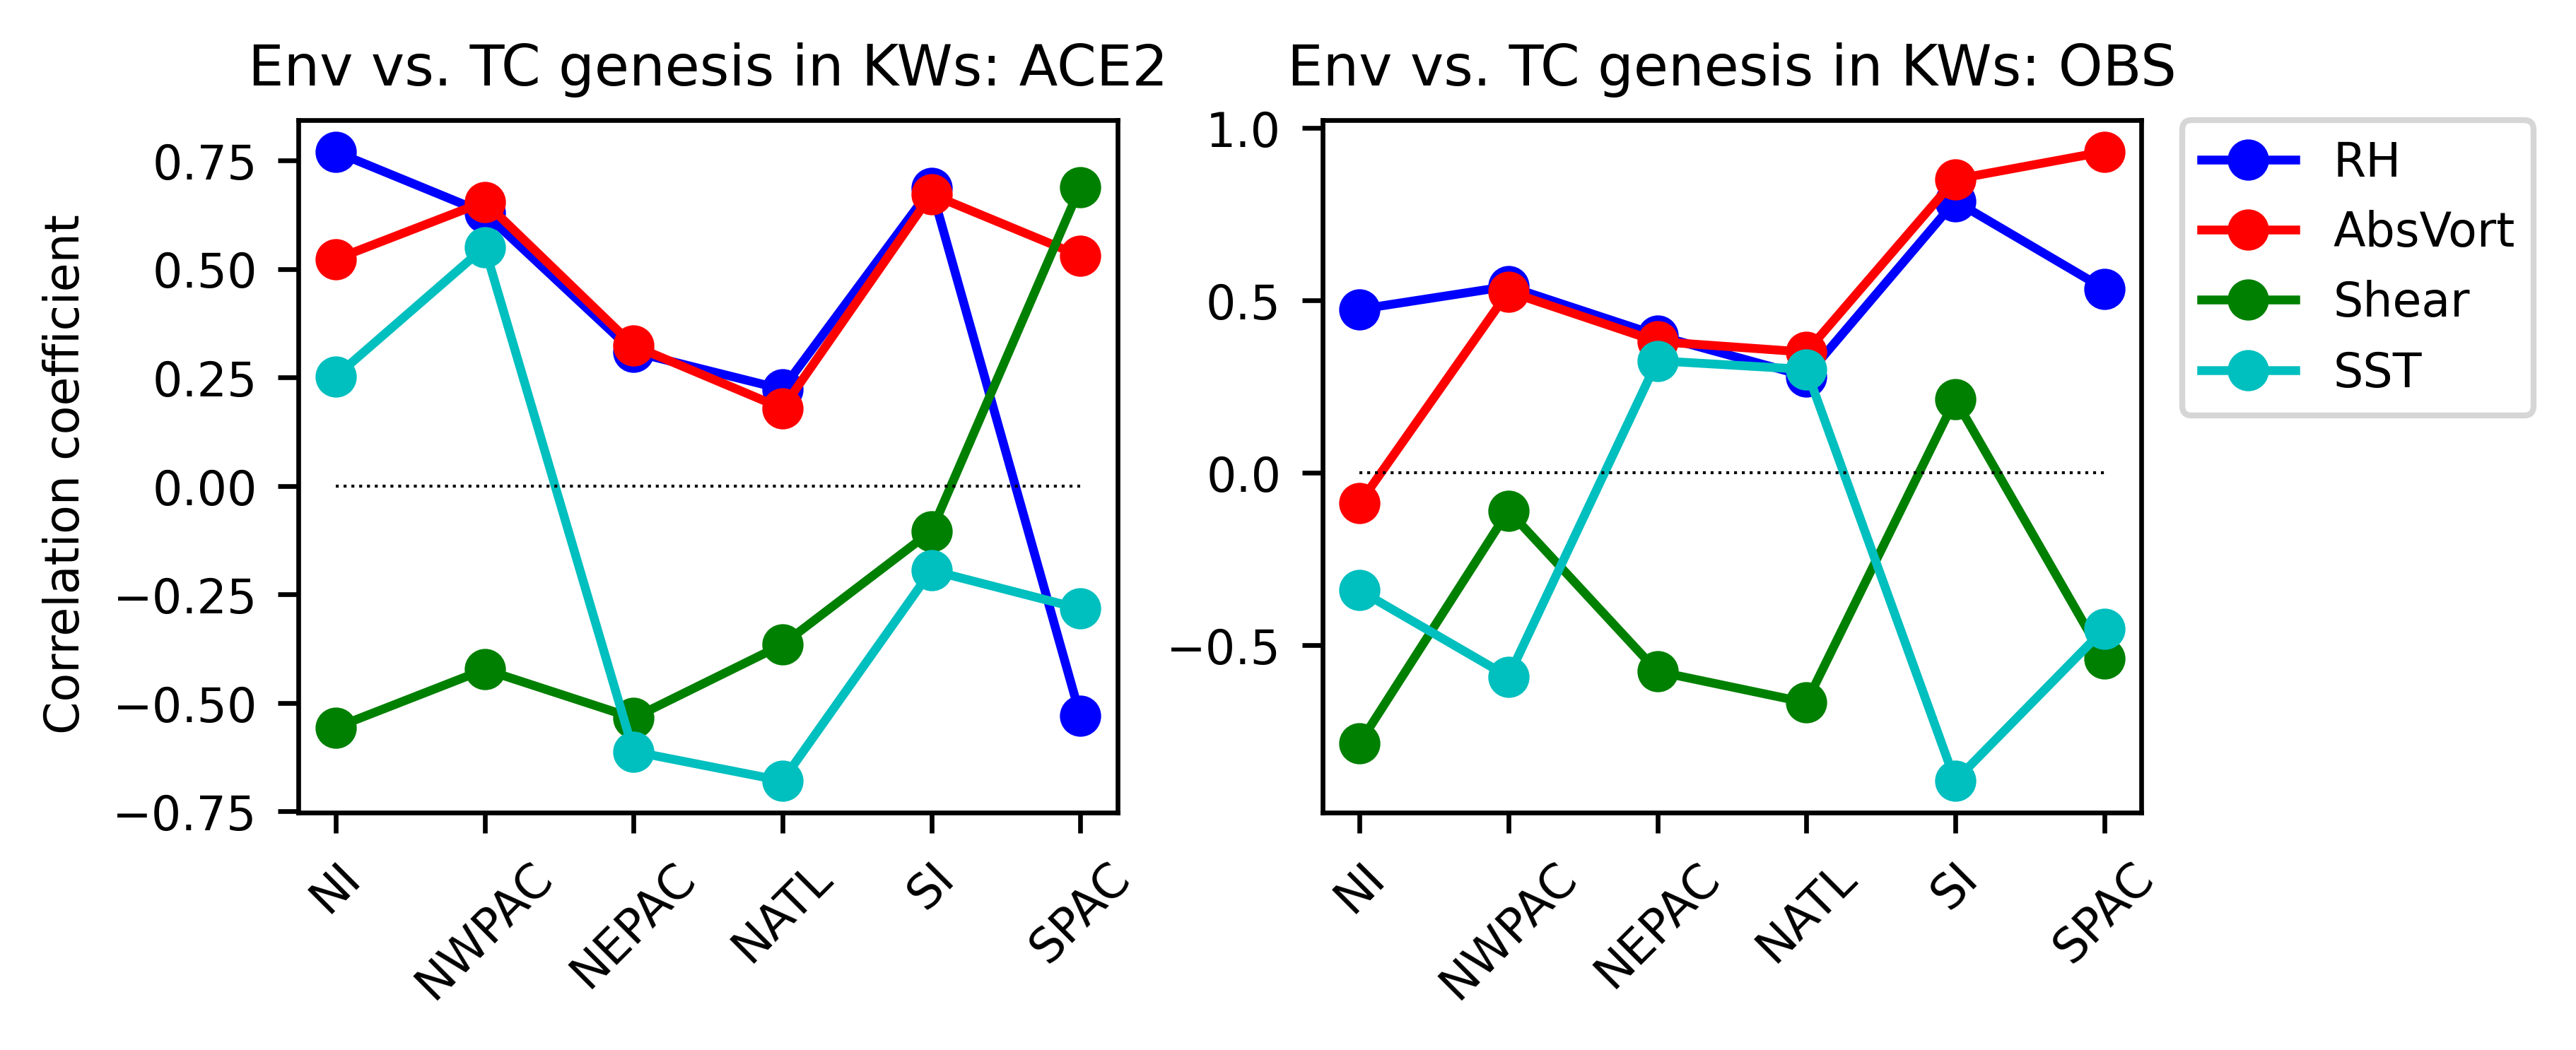

In [136]:
fig_name = 'Fig.R5_KWcomposite_TC_envfactor_corrcoef.png'
fig = plt.subplots(1,2,figsize=(5.5, 2.4),dpi=600)
plt.subplots_adjust(left=0.2,right=0.99,top=0.88,bottom=0.2, hspace=0.8, wspace=0.25)
plt.rcParams.update({'font.size': 8})

basin = np.arange(0, 6, 1)
plt.subplot(1,2,1)
plt.plot(basin, corr_colrh_tc_ace2, 'b-o')
plt.plot(basin, corr_absvor_tc_ace2, 'r-o')
plt.plot(basin, corr_shear_tc_ace2, 'g-o')
plt.plot(basin, corr_sst_tc_ace2, 'c-o')
plt.xticks(basin, basin_list, rotation=45)
#plt.legend(['RH','AbsVort','Shear','SST'], bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.plot(basin, np.zeros([np.size(basin)]), color='k', linestyle=':', linewidth=0.5)
plt.ylabel('Correlation coefficient ')
plt.title('Env vs. TC genesis in KWs: ACE2')
#
plt.subplot(1,2,2)
plt.plot(basin, corr_colrh_tc_obs, 'b-o')
plt.plot(basin, corr_absvor_tc_obs, 'r-o')
plt.plot(basin, corr_shear_tc_obs, 'g-o')
plt.plot(basin, corr_sst_tc_obs, 'c-o')
plt.xticks(basin, basin_list, rotation=45)
plt.legend(['RH','AbsVort','Shear','SST'], bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.plot(basin, np.zeros([np.size(basin)]), color='k', linestyle=':', linewidth=0.5)
#plt.ylabel('Correlation coefficient ')
plt.title('Env vs. TC genesis in KWs: OBS')
plt.show()

# Load TCGI

In [9]:
# Load TCGI with 1 variable changing
data = np.load(file_dir_multi_yr_ace2_100yr+'TCGI_KW_lag_regression_basin_ace2_100yr_change1var.npz')
TCGI_shear_lag_kw_basin_ace2_avg = data['TCGI_shear_lag_kw_basin_ace2']
TCGI_col_rh_lag_kw_basin_ace2_avg = data['TCGI_col_rh_lag_kw_basin_ace2']
TCGI_abs_vor_clip_lag_kw_basin_ace2_avg = data['TCGI_abs_vor_clip_lag_kw_basin_ace2']
TCGI_relsst_lag_kw_basin_ace2_avg = data['TCGI_relsst_lag_kw_basin_ace2']
#
data = np.load(file_dir_multi_yr+'TCGI_KW_lag_regression_basin_era5_10yr_chang1var.npz')
TCGI_shear_lag_kw_basin_era5 = data['TCGI_shear_lag_kw_basin_era5']
TCGI_col_rh_lag_kw_basin_era5 = data['TCGI_col_rh_lag_kw_basin_era5']
TCGI_abs_vor_clip_lag_kw_basin_era5 = data['TCGI_abs_vor_clip_lag_kw_basin_era5']
TCGI_relsst_lag_kw_basin_era5 = data['TCGI_relsst_lag_kw_basin_era5'] 

# Load TCGI with all variables changing
data = np.load(file_dir_multi_yr_ace2_100yr+'TCGI_KW_lag_regression_basin_ace2_100yr.npz')
TCGI_lag_kw_basin_ace2_avg = data['TCGI_lag_kw_basin_ace2']
#
data = np.load(file_dir_multi_yr+'TCGI_KW_lag_regression_basin_era5.npz')
TCGI_lag_kw_basin_era5 = data['TCGI_lag_kw_basin_era5']

ibasin_goal = np.array([0, 1, 4, 5])

# Plot TCGI contribution

In [11]:
contribution_colrh_ace2 = np.mean(TCGI_lag_kw_basin_ace2_avg[:, ibasin_goal] * TCGI_col_rh_lag_kw_basin_ace2_avg[:, ibasin_goal])/np.mean(TCGI_lag_kw_basin_ace2_avg[:, ibasin_goal]**2)
contribution_absvor_ace2 = np.mean(TCGI_lag_kw_basin_ace2_avg[:, ibasin_goal] * TCGI_abs_vor_clip_lag_kw_basin_ace2_avg[:, ibasin_goal])/np.mean(TCGI_lag_kw_basin_ace2_avg[:, ibasin_goal]**2)
contribution_relsst_ace2 = np.mean(TCGI_lag_kw_basin_ace2_avg[:, ibasin_goal] * TCGI_relsst_lag_kw_basin_ace2_avg[:, ibasin_goal])/np.mean(TCGI_lag_kw_basin_ace2_avg[:, ibasin_goal]**2)
contribution_shear_ace2 = np.mean(TCGI_lag_kw_basin_ace2_avg[:, ibasin_goal] * TCGI_shear_lag_kw_basin_ace2_avg[:, ibasin_goal])/np.mean(TCGI_lag_kw_basin_ace2_avg[:, ibasin_goal]**2)

contribution_colrh_era5 = np.mean(TCGI_lag_kw_basin_era5[:, ibasin_goal] * TCGI_col_rh_lag_kw_basin_era5[:, ibasin_goal])/np.mean(TCGI_lag_kw_basin_era5[:, ibasin_goal]**2)
contribution_absvor_era5 = np.mean(TCGI_lag_kw_basin_era5[:, ibasin_goal] * TCGI_abs_vor_clip_lag_kw_basin_era5[:, ibasin_goal])/np.mean(TCGI_lag_kw_basin_era5[:, ibasin_goal]**2)
contribution_relsst_era5 = np.mean(TCGI_lag_kw_basin_era5[:, ibasin_goal] * TCGI_relsst_lag_kw_basin_era5[:, ibasin_goal])/np.mean(TCGI_lag_kw_basin_era5[:, ibasin_goal]**2)
contribution_shear_era5 = np.mean(TCGI_lag_kw_basin_era5[:, ibasin_goal] * TCGI_shear_lag_kw_basin_era5[:, ibasin_goal])/np.mean(TCGI_lag_kw_basin_era5[:, ibasin_goal]**2)

print('Contribution to TCGI from colrh, absvor, relsst, shear (ACE2):')
print(contribution_colrh_ace2, contribution_absvor_ace2, contribution_relsst_ace2, contribution_shear_ace2)
print('--------------------------------')
print('Contribution to TCGI from colrh, absvor, relsst, shear (obs):')
print(contribution_colrh_era5, contribution_absvor_era5, contribution_relsst_era5, contribution_shear_era5)
print('--------------------------------')
print('Conclusion: Colrh plays a major role, and absvor plays a supplementary role!')

# Save relative contribution of each term
#np.savez(file_dir_ace2_100yr+'TCGI_each_term_contribution_ace2_100yr.npz',
#         contribution_colrh=contribution_colrh, contribution_absvor=contribution_absvor,\
#        contribution_relsst=contribution_relsst, contribution_shear=contribution_shear)

Contribution to TCGI from colrh, absvor, relsst, shear (ACE2):
0.2731483056364556 0.061316860454654544 0.0005123833622210377 -0.016842139937808708
--------------------------------
Contribution to TCGI from colrh, absvor, relsst, shear (obs):
0.2201159844217224 0.05363069014815205 -0.01248124026769622 0.0020460807217977323
--------------------------------
Conclusion: Colrh plays a major role, and absvor plays a supplementary role!


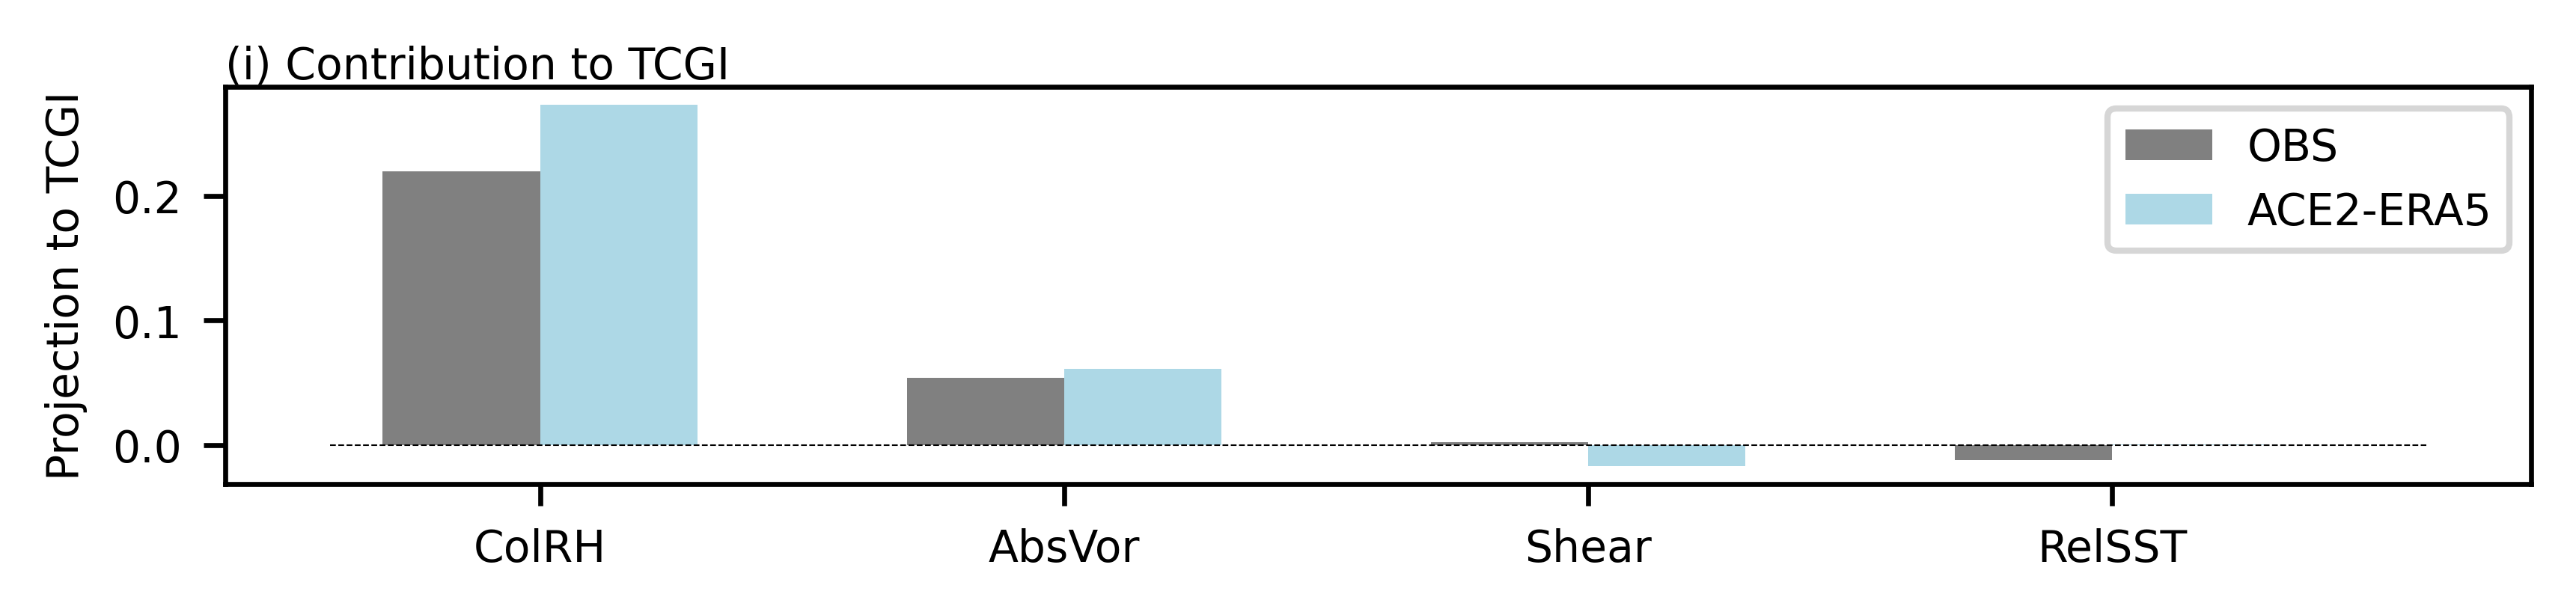

In [15]:
con_ace2 = np.array([contribution_colrh_ace2, contribution_absvor_ace2, contribution_shear_ace2, contribution_relsst_ace2])
con_obs = np.array([contribution_colrh_era5, contribution_absvor_era5, contribution_shear_era5, contribution_relsst_era5])
x = np.arange(0, 4)
x_extend = np.arange(-0.25, 4.5, 1)

fig_name = 'Fig.R3_TCGI_contribution.png'
fig = plt.subplots(1,1,figsize=(6.5, 1.3),dpi=600)
plt.subplots_adjust(left=0.2,right=0.99,top=0.88,bottom=0.2, hspace=0.8, wspace=0.2)
plt.rcParams.update({'font.size': 7})

plt.bar(x, con_obs, width=0.3, color='grey')
plt.bar(x+0.3, con_ace2, width=0.3, color='lightblue')
plt.legend(['OBS','ACE2-ERA5'])
plt.xticks(x+0.15, ('ColRH', 'AbsVor', 'Shear','RelSST'))
plt.plot(x_extend, np.zeros([5]), color='k', linewidth=0.25, linestyle='--')
plt.title('(i) Contribution to TCGI', pad=0.1, loc='left',fontsize=7)
plt.ylabel('Projection to TCGI')
plt.show()